# Recreating iPad Graphics with Plotnine

## Introduction

For the last six years, I have been collecting rainfall data at Coolum Beach, Queensland.  I have been processing the data on an iPad, using Apple Numbers, and generating a number of charts and graphs.

I decided to see how hard it would it would be to use Plotnine to generate similar charts.  Most of the iPad charts have been heavily modified from the defaults, via the tweaking user interface (things like colors, line widths, etc).  The main aim of the charts is to see if there any visible patterns in the rainfall.

## Implementation

### Set up Notebook magics

```lab_black``` formats the code, ```watermark``` provides reproducability information

In [1]:
%load_ext lab_black

In [2]:
%load_ext watermark

### Import libraries

I am not a great fan of ```from plotnine import *```, and I decided that all Plotnine methods would be explicitly declared.  It make the code a triffle more verbose, but also makes it clear what is coming from Plotnine

In [3]:
import pandas as pd
import numpy as np
import plotnine as p9

-----------------------

## Read Data

The iPad spreadsheet can be converted to Excel format for export.  We specify:

+ the spreadsheet name
+ the tab or sheet with the spreadsheet
+ the column numbers that we want from that sheet
+ the data types of each colum (if needed)
+ the numer of rows to process
+ the number of initial rows to skip
+ the names of the columns in the resulting DataFrame
+ where the original iPad sheet has an empty cell, Excel / Pandas gives me Not-A-Number.  I convert these to zeros with the ```fillna()``` call

In fact, the iPad spreadsheet contains many tabs as I found it easier to have a single data entry tab, and then to compute averages, etc, in separate tables in seperate tabs.  This made creating iPad charts vastly easier. 

```DoY``` is the day number within any given year (running 1-366 in leap years, 1-365 otherwise).

In [4]:
SS_PATH = "data/Rainfall 4.xlsx"
SHEET = "Data Entry"
type_dict = {"Day of Year": int}

rain_df = pd.read_excel(
    SS_PATH,
    SHEET,
    usecols=[0, 4, 5, 6, 7, 8, 9, 10],
    dtype=type_dict,
    nrows=366,
    skiprows=3,
    names=[
        "DoY",
        "2020",
        "2021",
        "2022",
        "2023",
        "2024",
        "2025",
        "2026",
    ],
    header=None,
).fillna(0)

### Examine the imported DataFrame

Show the first few rows

In [5]:
rain_df.head(2)

,DoY,2020,2021,2022,2023,2024,2025,2026
0,1,0.0,24.0,16.0,0.0,0.0,0.5,2.5
1,2,0.0,0.0,7.0,0.0,92.0,1.5,0.0


Show the last few rows

In [6]:
rain_df.tail(2)

,DoY,2020,2021,2022,2023,2024,2025,2026
364,365,5.5,0.5,4.0,66.0,15.0,0.0,0.0
365,366,22.0,0.0,0.0,0.0,0.0,0.0,0.0


Confirm the column names are really strings

In [7]:
rain_df.columns

Index(['DoY', '2020', '2021', '2022', '2023', '2024', '2025', '2026'], dtype='object')

Check the data types of the columns

In [8]:
rain_df.dtypes

DoY       int64
2020    float64
2021    float64
2022    float64
2023    float64
2024    float64
2025    float64
2026    float64
dtype: object

----------------------
## Convert DataFrame from ```wide``` to ```long```

Plotnine is based upon ```ggplot2```, which is part of the ```R``` and ```tidy``` universe.  This universe has a very strong opinion about DataFrame layout:  there is only one column that holds observed data of a given type, and the other columns in any given row describe / specify the context of the observation.

So in my DataFrame above, I have broken this rule.  I have multiple columns (one for each year) that hold rainfall observations:  we now set about transforming my DataFrame from ```wide``` format to ```long``` format.

### DateTimes from Day of Year and Year
We do a trial run of generating a date string consisting of a 4 digit year followed by a day-of-year (DoY).  We use Pandas function to turn the DoY values into a string, and the Pandas ```to_datetime``` method, using the codes for string-to-date formatting (```%Y% ```-> four digit year, ```%j%``` -> day-of-year).  For the first year column (2020, a leap year), this works OK, spanning the whole year.

In [9]:
year_str = rain_df.columns[1]
pd.to_datetime(
    year_str + rain_df["DoY"].astype(str), format="%Y%j"
)

0     2020-01-01
1     2020-01-02
2     2020-01-03
3     2020-01-04
4     2020-01-05
         ...    
361   2020-12-27
362   2020-12-28
363   2020-12-29
364   2020-12-30
365   2020-12-31
Name: DoY, Length: 366, dtype: datetime64[ns]

Things are a little less happy for non-leap years.  My iPad spreadsheet has DoY running from 1 to 366, so the generated DateTime array has its last value in the next year.

In [10]:
year_str = '2021'
pd.to_datetime(
    year_str + rain_df["DoY"].astype(str), format="%Y%j"
)

0     2021-01-01
1     2021-01-02
2     2021-01-03
3     2021-01-04
4     2021-01-05
         ...    
361   2021-12-28
362   2021-12-29
363   2021-12-30
364   2021-12-31
365   2022-01-01
Name: DoY, Length: 366, dtype: datetime64[ns]

We now create a seperate Pandas DataFrame for each year, with special handling for non-leap years (we skip the last row, corresponding to day-of-year 366)

In [11]:
# list of Pandas dataframe, one for each year
year_dfs = []

# loop over all years in our loaded-from-excel dataframe
for y in rain_df.columns[1:-1]:
    # indicate progress
    print(f'Doing year {y}')

    # convert the day-of-year numbers for this year into datetimes, parsing generated strings
    year_dates = pd.to_datetime(
        y + rain_df["DoY"].astype(str), format="%Y%j"
    )

    # handle non-leap years by skipping last value (day-of-year = 366 no valid for a non-leap year)
    if int(y) % 4 == 0:
        year_rain = rain_df[y]
    else:  # not a leap year
        year_dates = year_dates[:-1]
        year_rain = rain_df[y][:-1]
    # end if

    # build a dataframe from two arrays, datetime values, and rainfall values
    year_df = pd.DataFrame(
        {'date': year_dates, 'rain': year_rain}
    )
    # add to list of dataframes
    year_dfs.append(year_df)
# end for

Doing year 2020
Doing year 2021
Doing year 2022
Doing year 2023
Doing year 2024
Doing year 2025


Check the last few rows of the last dataframe in list - looks OK

In [12]:
year_dfs[-1].tail(2)

,date,rain
363,2025-12-30,0.0
364,2025-12-31,0.0


### Build ```long``` DataFrame
We now use Pandas to concatenate to multiple DataFrames we have built.

In [13]:
rain_df2 = pd.concat(year_dfs)

Check the first few rows, and last few rows.  Dates and rainfall values look OK.

In [14]:
rain_df2.head(2)

,date,rain
0,2020-01-01,0.0
1,2020-01-02,0.0


In [15]:
rain_df2.tail(2)

,date,rain
363,2025-12-30,0.0
364,2025-12-31,0.0


-----------------------------
## Plot all rain readings 

The first (and most obvious) plot is  a simple scatter plot of rainfall against time.  In the Plotnine world, there are some subtle points to notice.

The general mental model is that we create an empty plot by the ```ggplot``` call, and then create one or more layers to go on the plot. In some sense, Plotnine / ggplot2 is like Cascading Style Sheets:  the initial call to ```ggplot()```specifies the DataFrame that is the default data source for subsequent Plotnine method calls. Then various attributes of the plot can be tweaked (size of plot, colors used, etc).  To demonstrate, in the code below we create an object ```p1``` by creating an empty plot, and then adding a layer of points.
Each point gets its x-axis value from the ```date``` column of the input DataFrame, and the y-axis value from the ```rain``` column of the input DataFrame.  further, the color of each point is derived from the year of the date value.  We could have created a ```year``` column in our dataframe, but Plotnine is smart enough to see ```date.dt.year```, and know that this means to take the ```date``` column, treat it as a datetime (```dt```), and extract the year.  Plotnine also sees the wrapping function ```factor```, and knows to treat the year value a categorical (non-continuous) values, and not as integer values.

Hidden behind all this is a big Plotnine concept: that of ```scale```.  We have specified that the position of the x axis for each point is related to values in the ```date```column, and similarly for the y axis position (related to ```rain``` vaues), and the color of the fill of each point related to the ```year```.  The exact details of how a date value maps onto an x-axis position, or how a year value maps to a color is specified in calls to methods of the type ```scale_...```.  In the example below, we call ```scale_color_brewer```, to specify the palette to be used.  We accept the default (linear scale) mapping of date to x-axis position, and rain to y-axis position.

We modify our plot by setting the height and width, and the color palette to use in coloring the points (as described above).  The ```qual``` type of color palette is used with categorical variables, where there is no meaning as small-to-big, and all we want the coloring to do is distinguish between different years.  Now in this case, we actually __do__ have a small-to-big in our sequence of years, but this is not relevant to our chart (so we declare ```year``` to be a ```factor```).

Note that this is a prototype:  eventually we would need to tidy-up the legend name, fix the format of the labels on the x axis, put on a title, etc.  In any case, we can see the this tupe of chart doesn't lend itself to discerning patterns in rainfall, so we move on.

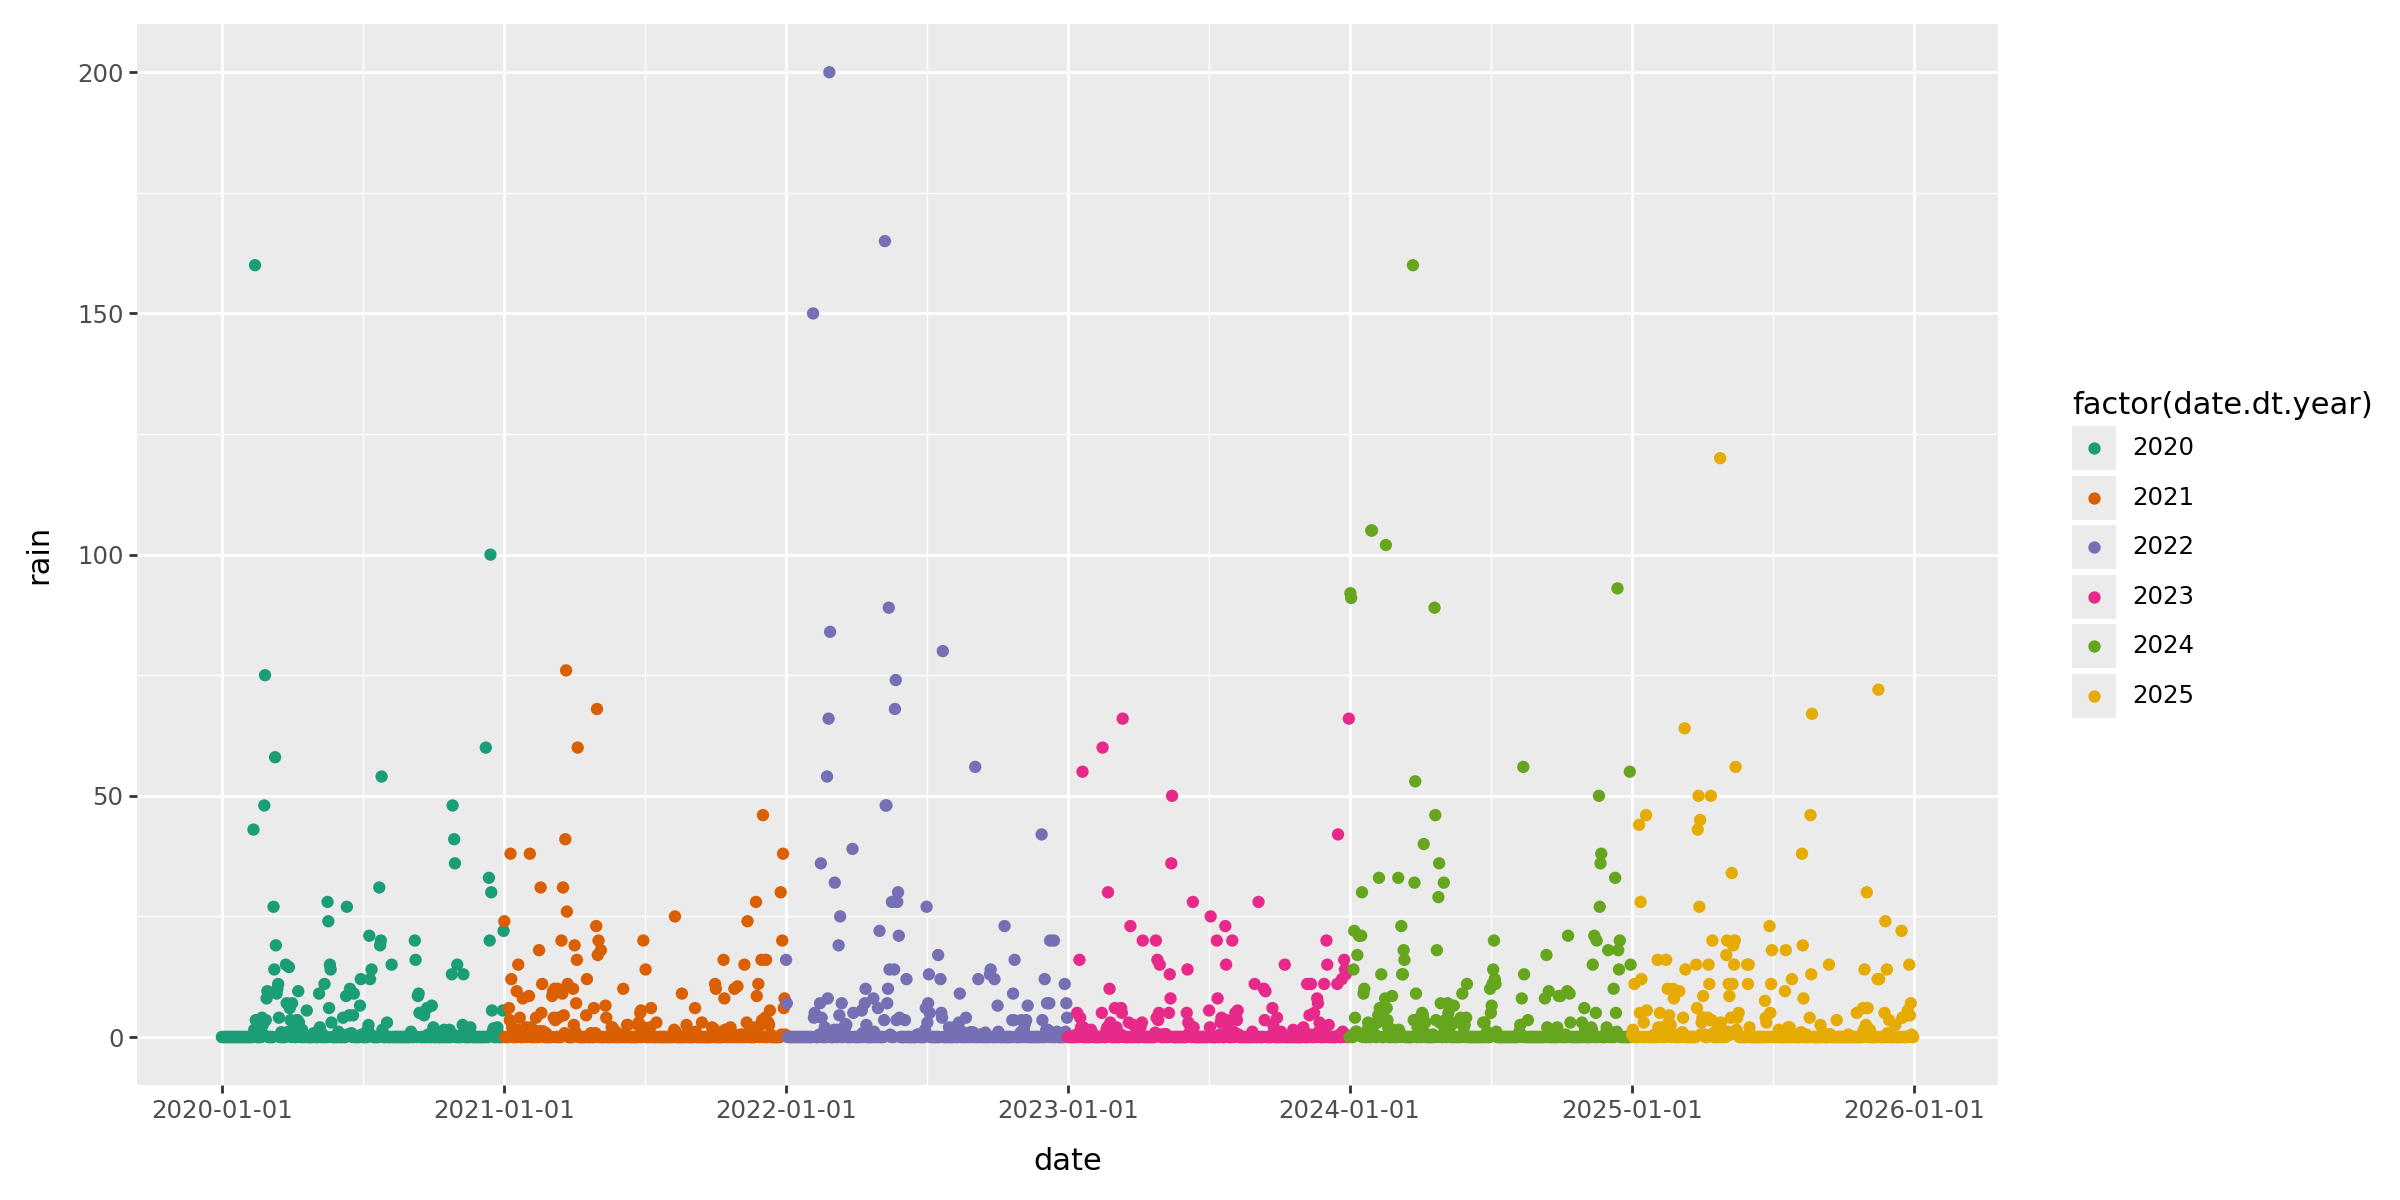

In [16]:
p1 = p9.ggplot(  # create empty plot, setting the default data source
    data=rain_df2,
) + p9.geom_point(  # create layer with points
    mapping=p9.aes(
        x='date', y='rain', color='factor(date.dt.year)'
    )
)
width = 12
height = 6
(
    p1  # take newly created plot,
    + p9.theme(
        figure_size=(width, height)
    )  # adjust the default size
    + p9.scale_color_brewer(  # adjust the default palette of points
        type='qual',
        palette='Dark2',
    )
)

## Plot rain readings, overlapping years

We take the same code as before, and make two changes.  First, we map x-axis position to the day-of-year number, and we set the y-axis minimum to 1 (to hide the clutter from all days when it didn't rain).


C:\Users\donrc\anaconda3\envs\r_python\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1532 rows containing missing values.


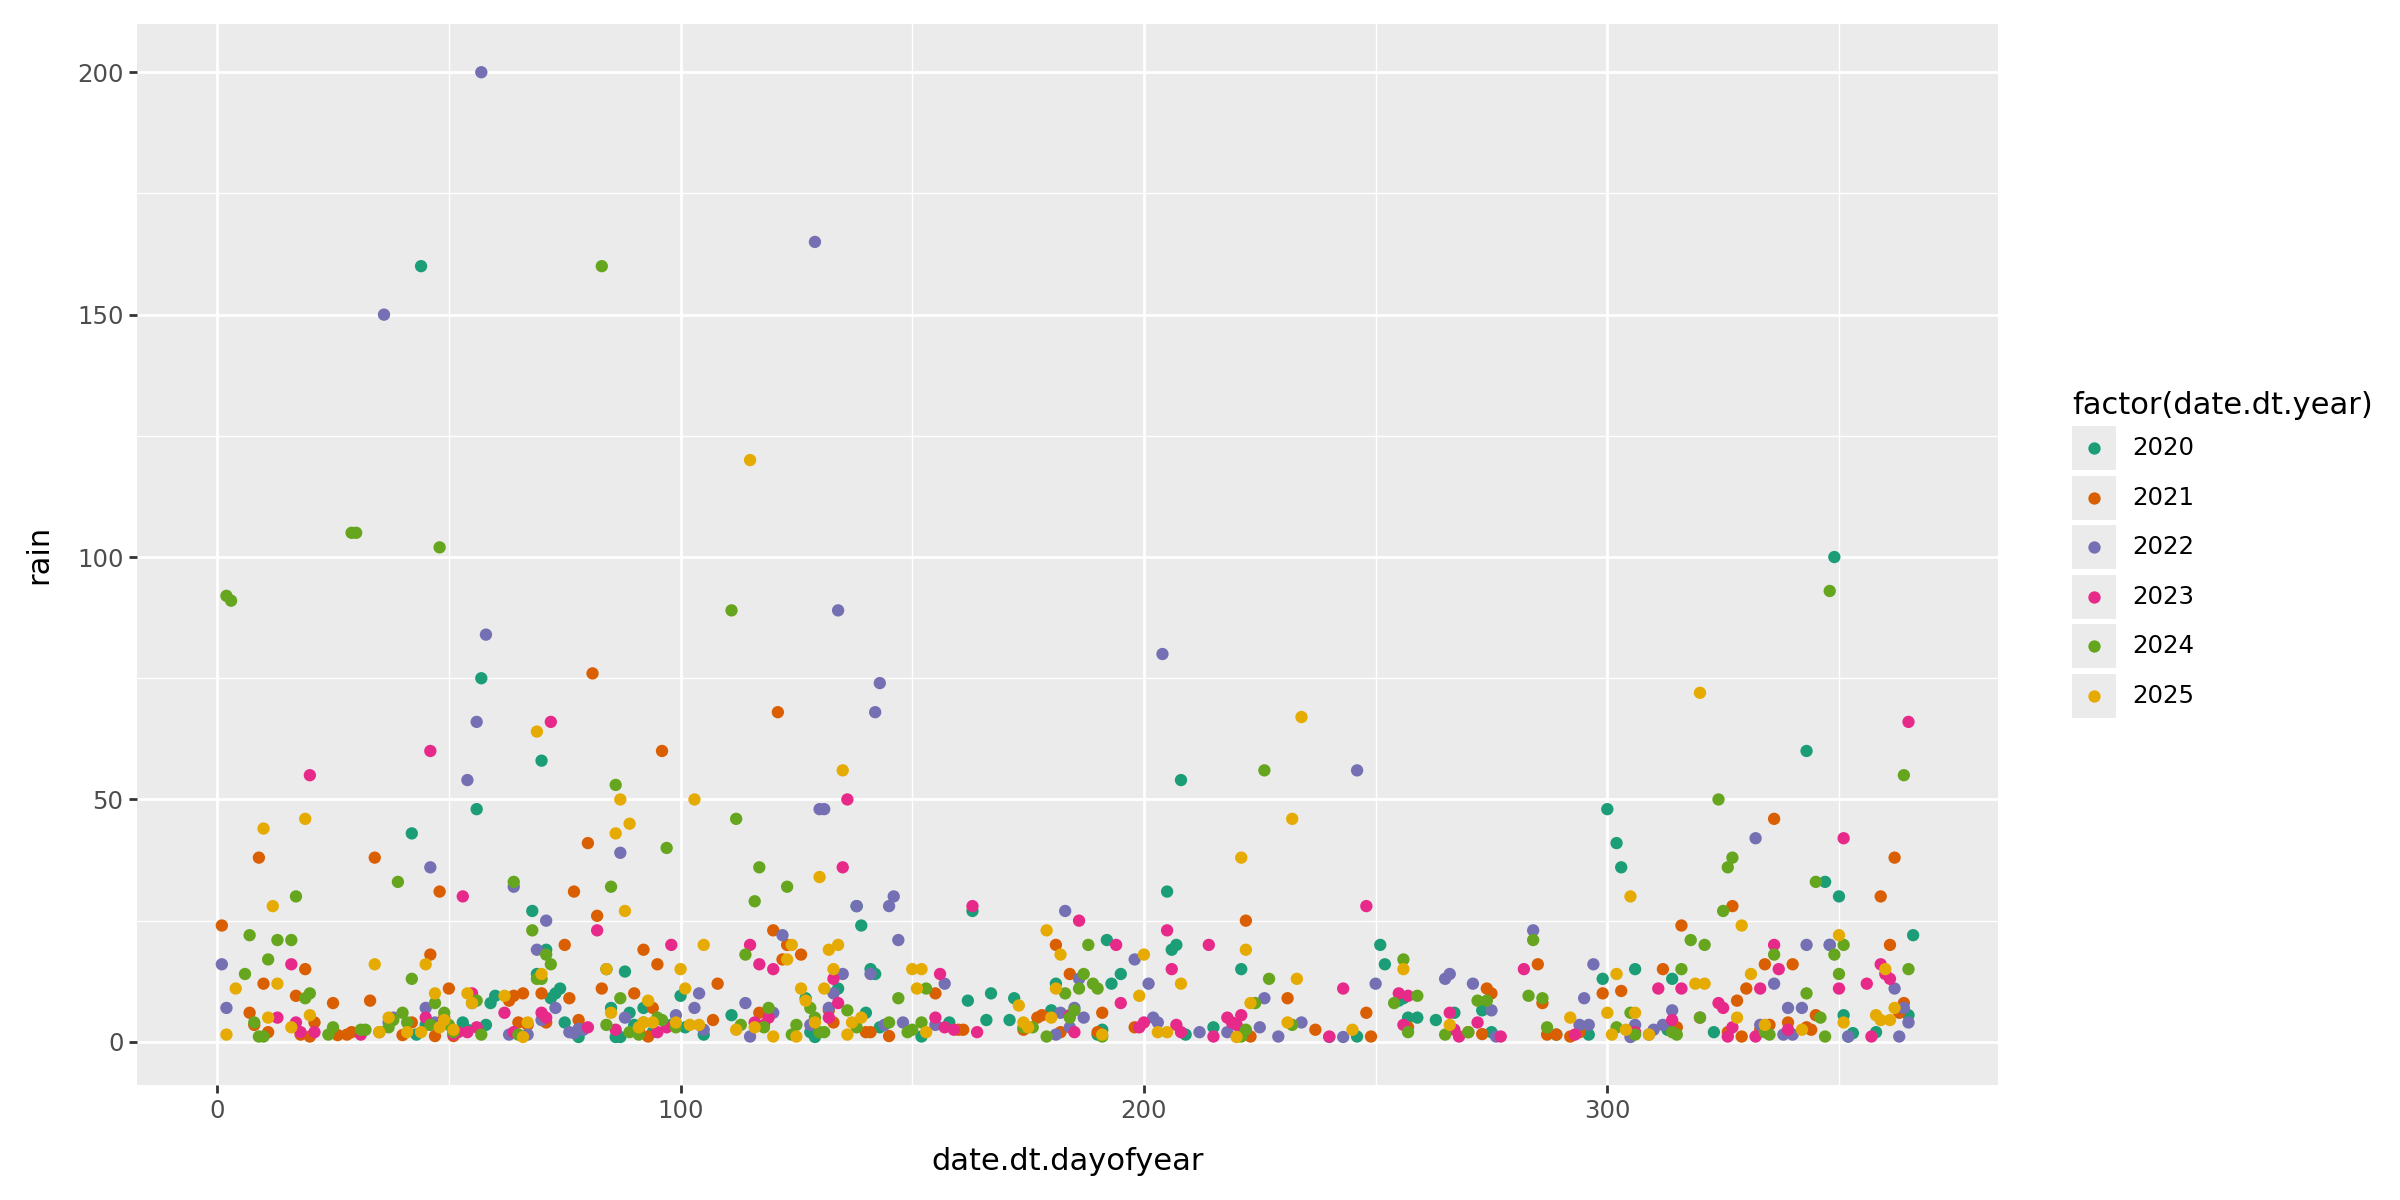

In [17]:
p1 = p9.ggplot(
    data=rain_df2,
) + p9.geom_point(
    mapping=p9.aes(
        x='date.dt.dayofyear',
        y='rain',
        color='factor(date.dt.year)',
    )
)
width = 12
height = 6
(
    p1
    + p9.theme(figure_size=(width, height))
    + p9.scale_color_brewer(
        type='qual',
        palette='Dark2',
    )
    + p9.ylim((1, None))
)

-----------------
## iPad comparison

Compare this to the iPad equivalent.  I had hand-selected the iPad palette, and had special-cased the last year (2026) to have a bigger symbol, and a different shape.  This is possible in Plotnine, but would be clumsy.  Overall, the two plots are comparable (given that I haven't fixed the x-axis, y-axis labels, nor the plot and  legend titles).  In the examples below, we move to a Plotnine theme that has a pure white background. 

![](images/daily.png)

## Plot rain readings, overlapping years, log10 plot

If we want to bring out the detail of the days with lower rainfall, we can use a log10 scale for the y-axis.  We achieve this by the ```p9.scale_y_log10``` call: apart from a slight change the y-axis limits (before the log10 transformation is applied), the code is the same.  This gives us a weird row of points at the bootom of the plot.

C:\Users\donrc\anaconda3\envs\r_python\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
C:\Users\donrc\anaconda3\envs\r_python\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 119 rows containing missing values.


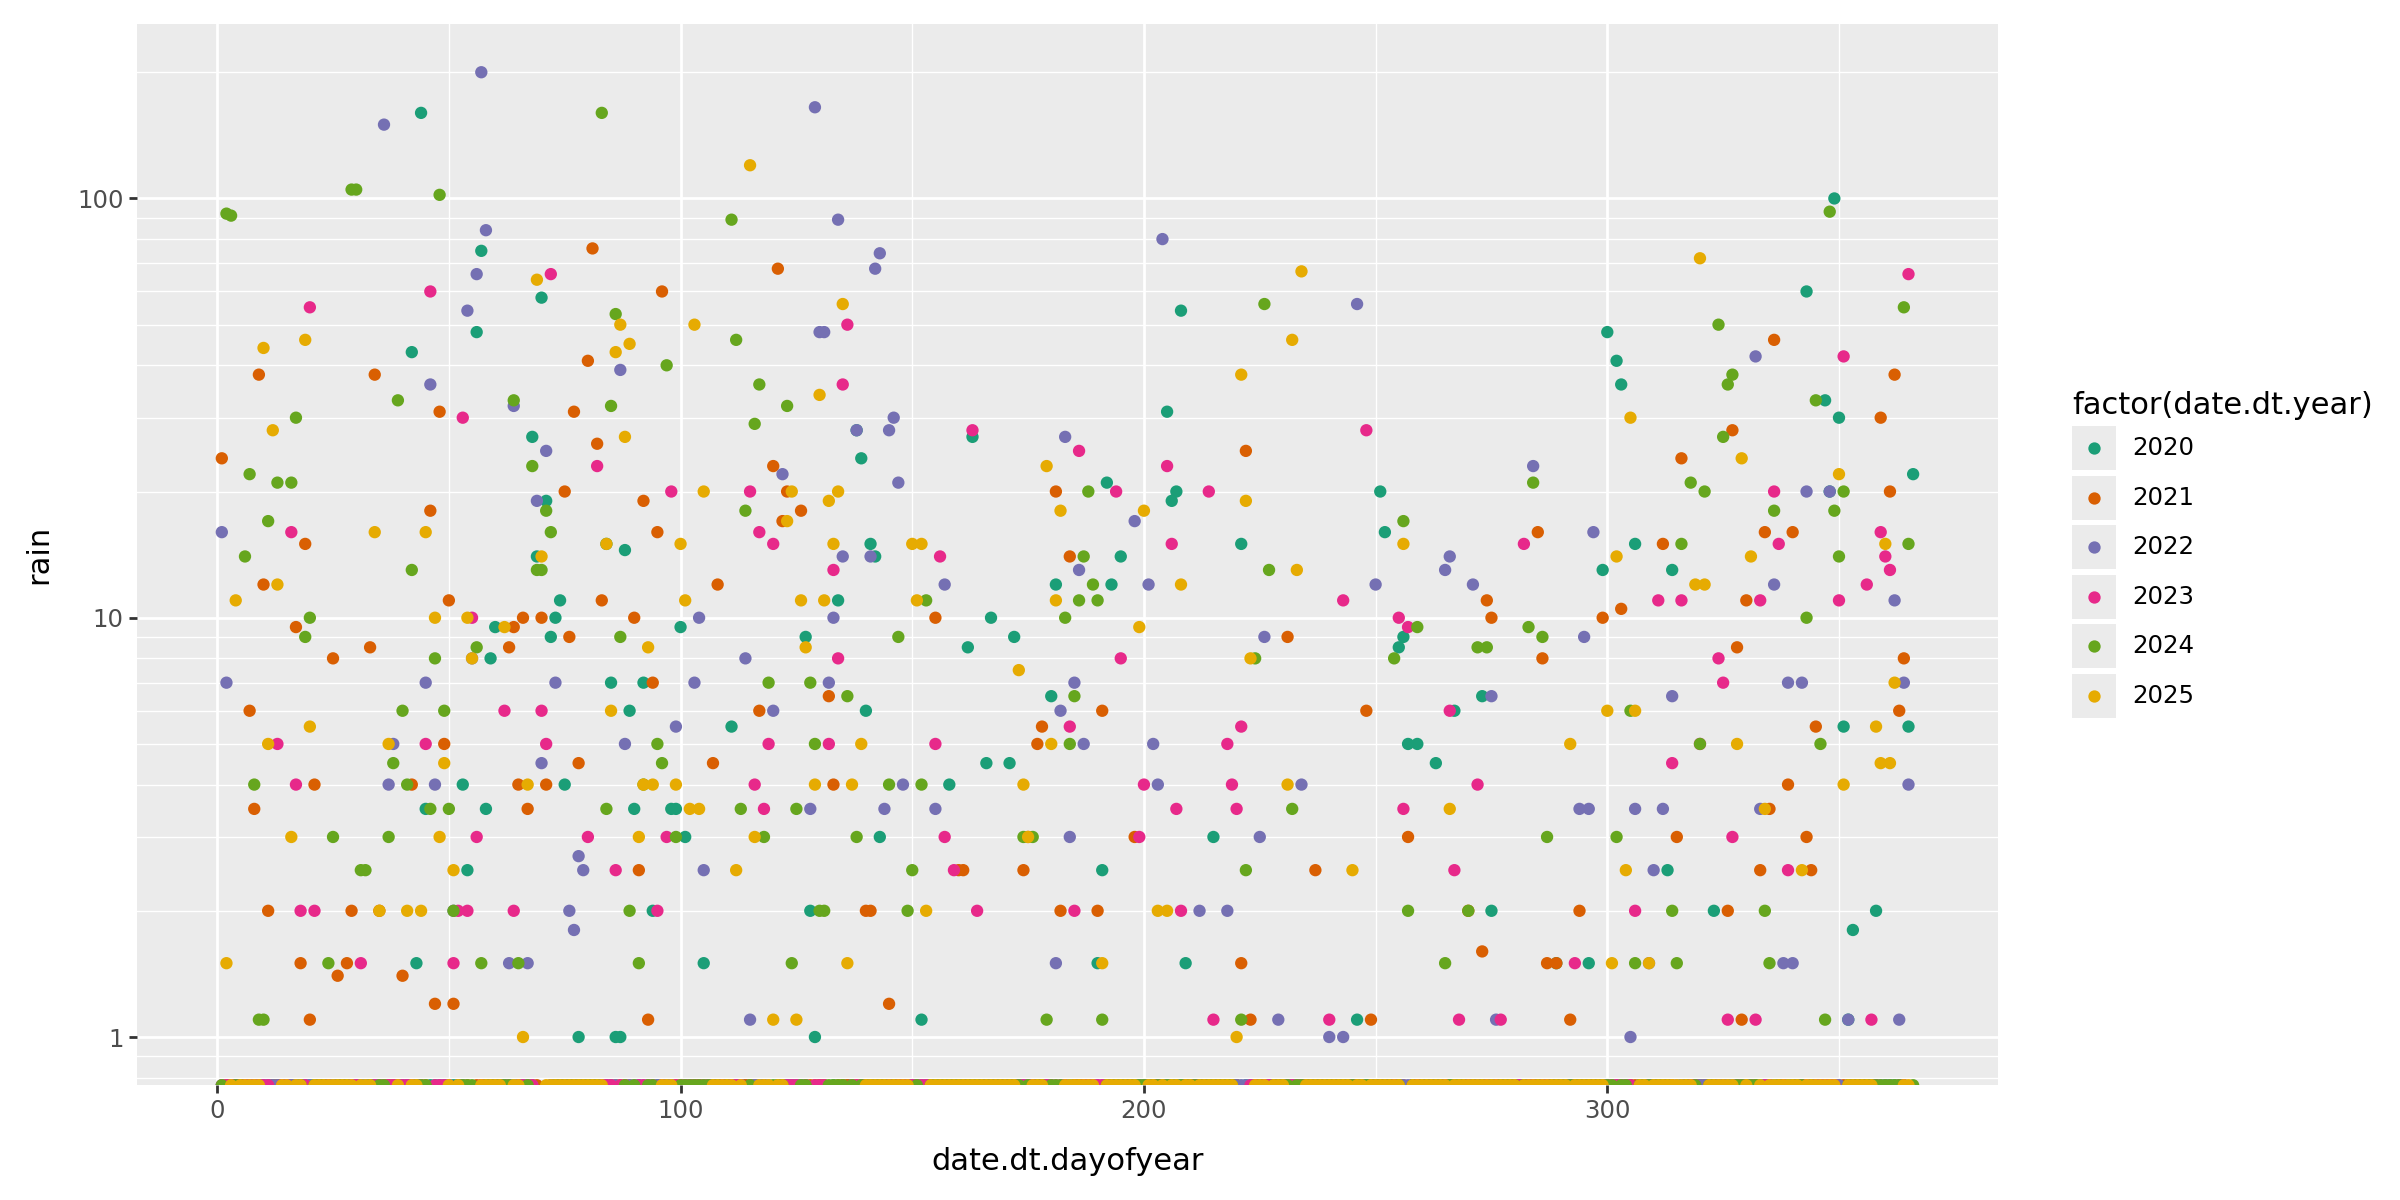

In [18]:
p1 = p9.ggplot(
    data=rain_df2,
) + p9.geom_point(
    mapping=p9.aes(
        x='date.dt.dayofyear',
        y='rain',
        color='factor(date.dt.year)',
    )
)
width = 12
height = 6
(
    p1
    + p9.theme(figure_size=(width, height))
    + p9.scale_color_brewer(
        type='qual',
        palette='Dark2',
    )
    + p9.scale_y_log10(
        limits=(1, 200),
    )
)

### Pandas to the rescue

We modify our ```ggplot``` call, to specify that we only want to plot rows with rain >1.  This fixes the row of points at the bottom of the plot.

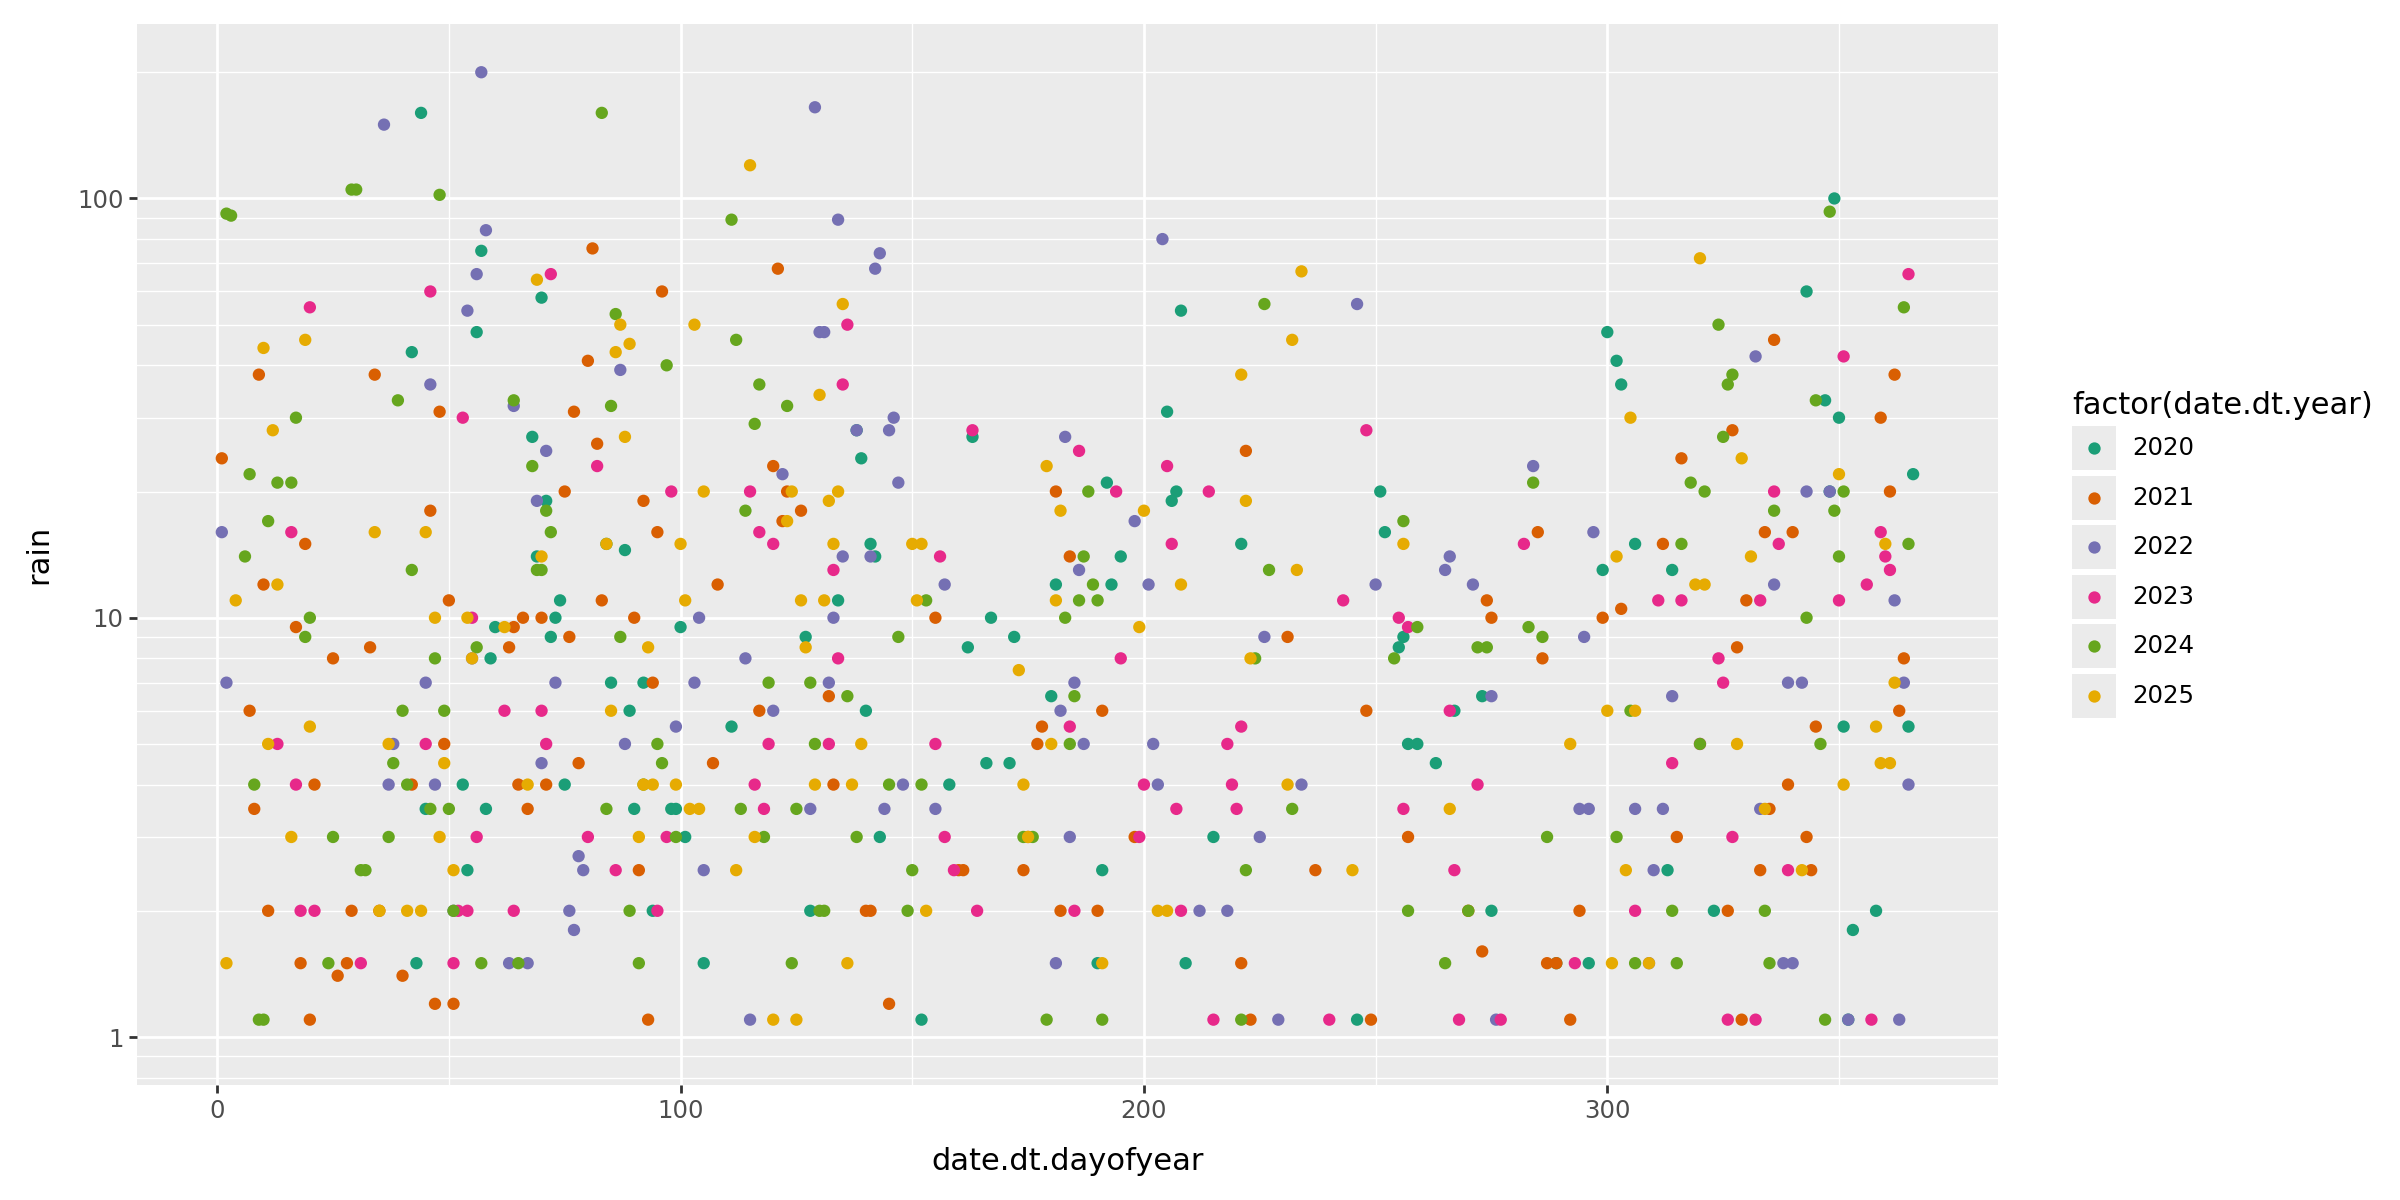

In [19]:
p1 = p9.ggplot(
    data=rain_df2[rain_df2['rain'] > 1],
) + p9.geom_point(
    mapping=p9.aes(
        x='date.dt.dayofyear',
        y='rain',
        color='factor(date.dt.year)',
    )
)
width = 12
height = 6
(
    p1
    + p9.theme(figure_size=(width, height))
    + p9.scale_color_brewer(
        type='qual',
        palette='Dark2',
    )
    + p9.scale_y_log10(
        limits=(1, 200),
    )
)

----------------------
## iPad comparison

As mentioned, the default log10 y-axis Plotnine plot has a curious line of points along the bottom of the plot  (maybe to show points that fall outside y-axis limits?).  Other than the missing labels and title (as for the previous example), I prefer the more punchy Legend of the iPad version.  In future, I will investigate theme options to try and recreate this style of Legend in Plotnine

![](images/daily_log10.png)

--------------------

## Show cumulative rainfall, overlapping years

In order to plot the cumulative rainfall for each year, we define a new column ```year```

In [20]:
rain_df2['year'] = rain_df2['date'].dt.year

Show the first few rows: all OK

In [21]:
rain_df2.head(2)

,date,rain,year
0,2020-01-01,0.0,2020
1,2020-01-02,0.0,2020


Check the data types: allOK

In [22]:
rain_df2.dtypes

date    datetime64[ns]
rain           float64
year             int32
dtype: object

We now group all the rows that share a common year value, and perform a cumulative sum operation on each group.

In [23]:
cum_rain = rain_df2.groupby('year')['rain'].cumsum()

Assign the cumulative rainfall to create a new column ```cum_rain```

In [24]:
rain_df2['cum_rain'] = cum_rain

Finally, I have decided to fix the labels and titles on my plots.  In Plotnine, this is done in a single call that sets all (non-default) labels and titles in one call.  I decided to have no title for my line color legend (```guide``` in Plotnine parlance) - in this case, just unnecessary chart-junk.

In [25]:
labels = p9.labs(
    y='Rain (mm)',
    color=' ',
    x='Day in Year',
    caption='Coolum Beach rain gauge',
    subtitle='Cumulative rainfall',
)

As before, we create any empty plot (specifying the data source), and now we add a layer of lines.  The line will be colored according to the year value.  We accept the default x-axis and y-axis scale, and the default mapping of year value to line color.  Finally we set the plot size (via a theme call) and set the labels

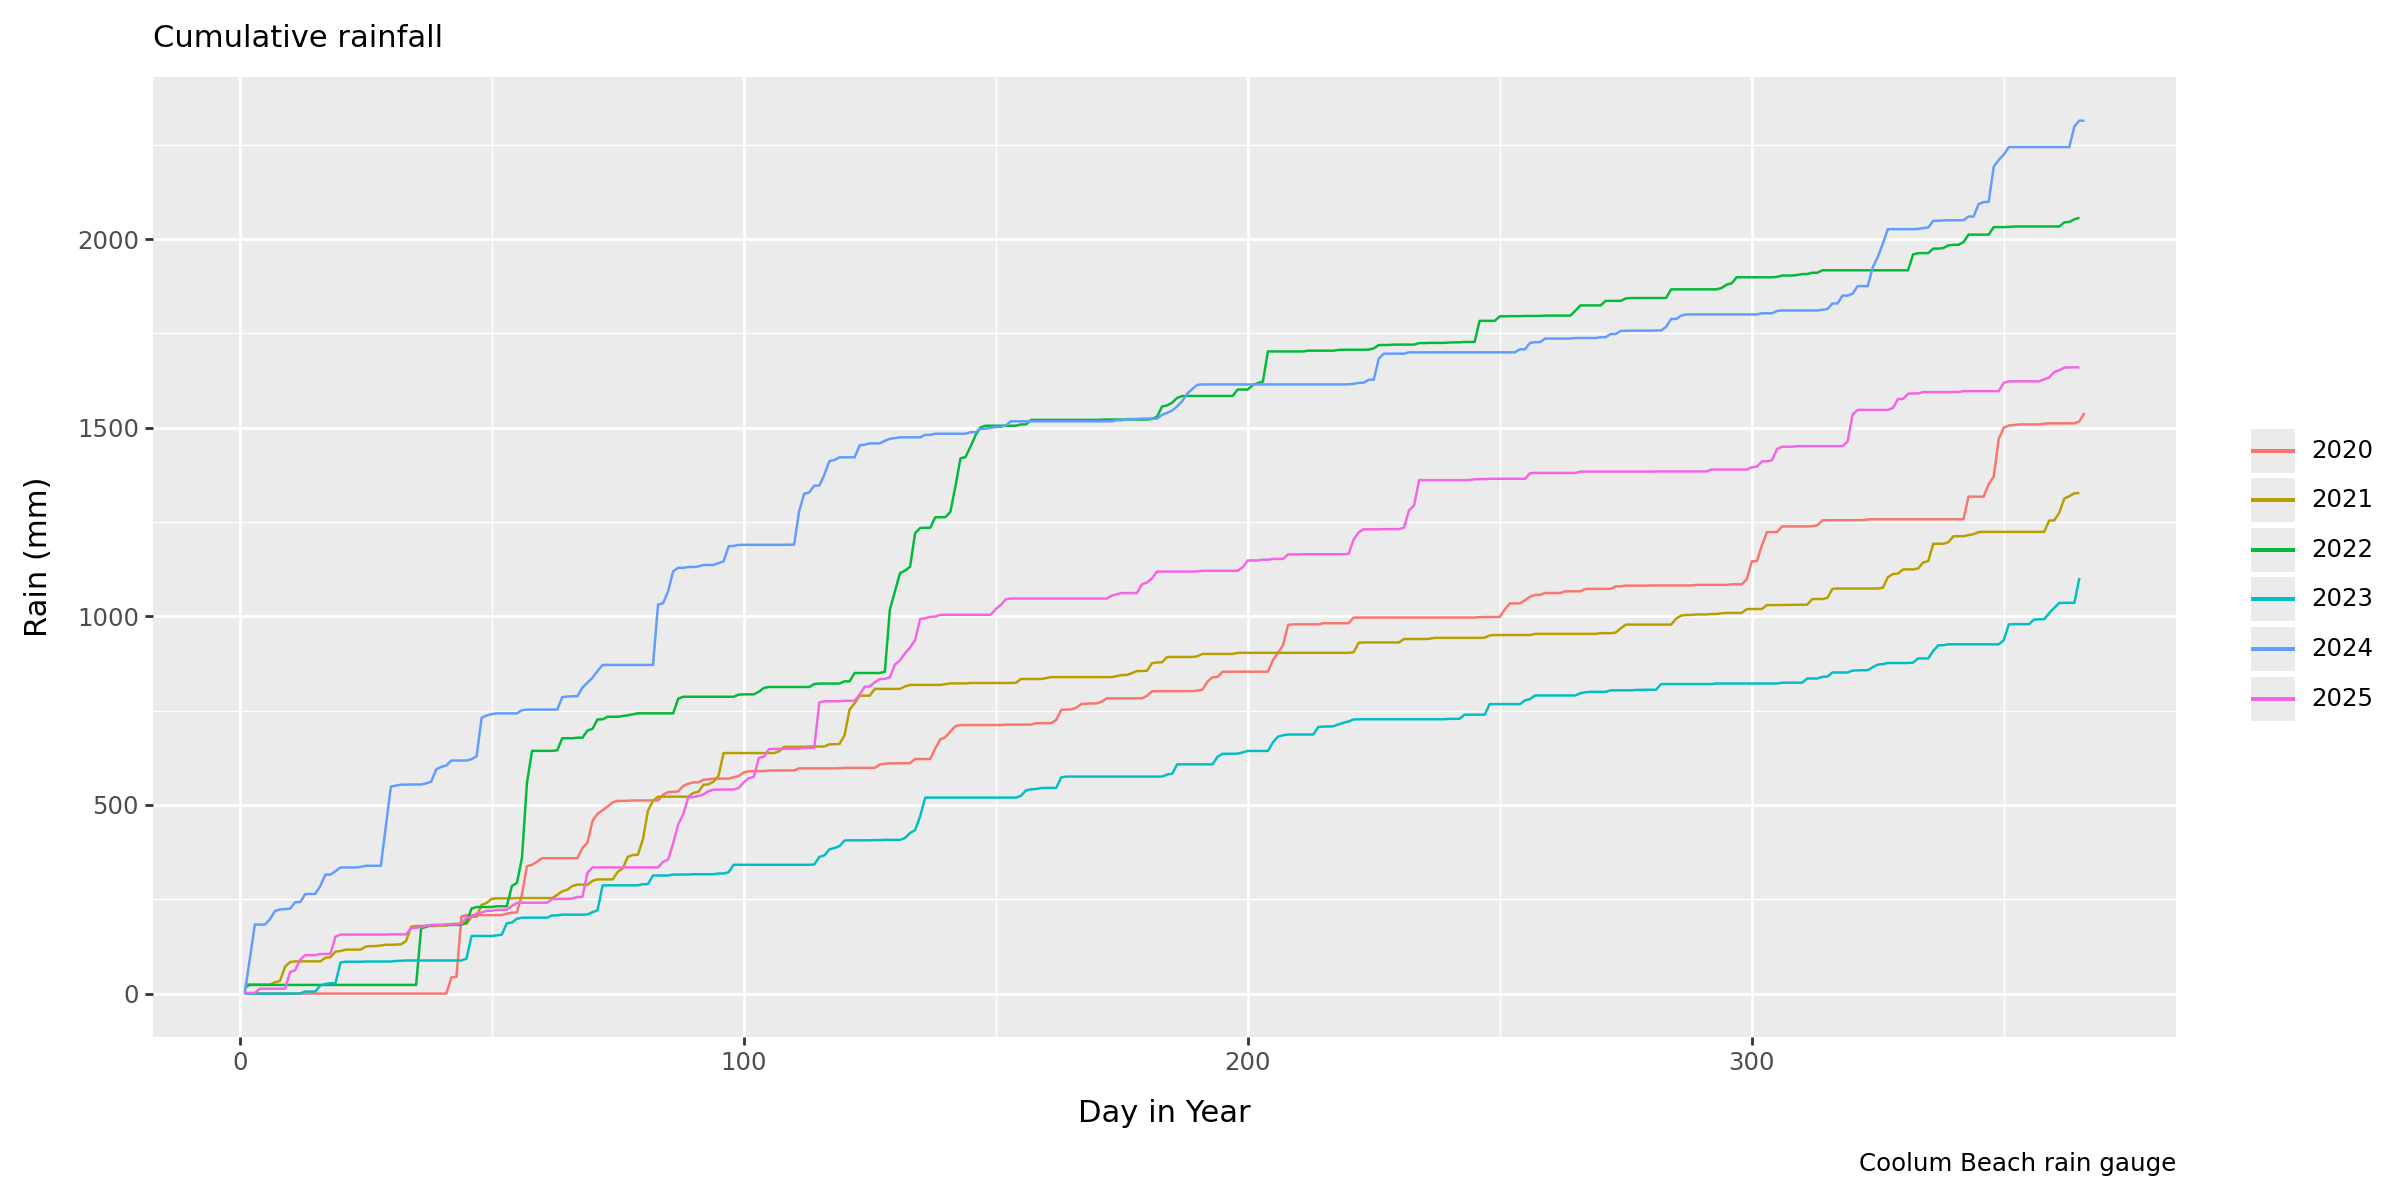

In [26]:
p1 = p9.ggplot(
    data=rain_df2,
) + p9.geom_line(
    mapping=p9.aes(
        x='date.dt.dayofyear',
        y='cum_rain',
        color='factor(year)',
    )
)

width = 12
height = 6
(p1 + p9.theme(figure_size=(width, height)) + labels)

---------------------

## iPad comparison

The two plots (iPad below, Plotnine above) are effectively equivalent


![](images/cum_year.png)

---------------------

## Show rain by Quarter

We use Pandas to create a new column, holding the Quarter of the year for each row. 
We  group by year, and by quarter within year, and sum the rain values for each group.

We create a new DataFrame just holding quarter-summed rainfall data (we have to reset the index)

In [27]:
rain_df2['qtr'] = rain_df2['date'].dt.quarter

In [28]:
q_sum = rain_df2.groupby(['qtr', 'year'])['rain'].sum()

In [29]:
q_sum_df = pd.DataFrame(q_sum)

In [30]:
q_sum_df2 = q_sum_df.reset_index(level=['qtr', 'year'])

Show the first few rows of our new DataFrame

In [31]:
q_sum_df2.head()

,qtr,year,rain
0,1,2020,560.0
1,1,2021,532.1
2,1,2022,787.0
3,1,2023,316.5
4,1,2024,1132.3


Create the labels and title for our plot

In [32]:
labels = p9.labs(
    y='Rain (mm)',  # y axis label
    fill='Qtr',  # legend title
    x='Year',  # x axis label
    caption='Coolum Beach rain gauge',  # text under plot
    subtitle='Rainfall by quarter',  # less punchy title for plot
)

We:
+ create and empty plot for our data source
+ add a layer of columns where:
  +  each column is positioned according to year on the x-axis
  +  each column has a height according to the rainfall for that quarter
  +  each column is filled with a color according to the quarter number (1,2,3,4)
  +  each column is stacked, one on top of the other, with quarter 4 on top
+ in keeping with a watery theme, specify the fill colors that distinguish quarters to be varying shades of Blue in increasing intensity (the ```seq``` type parameter says we have a sequence of values)
+ supress the vertical gridlines by parameters in the theme call, as well as setting the plot size
+ set all labels and title

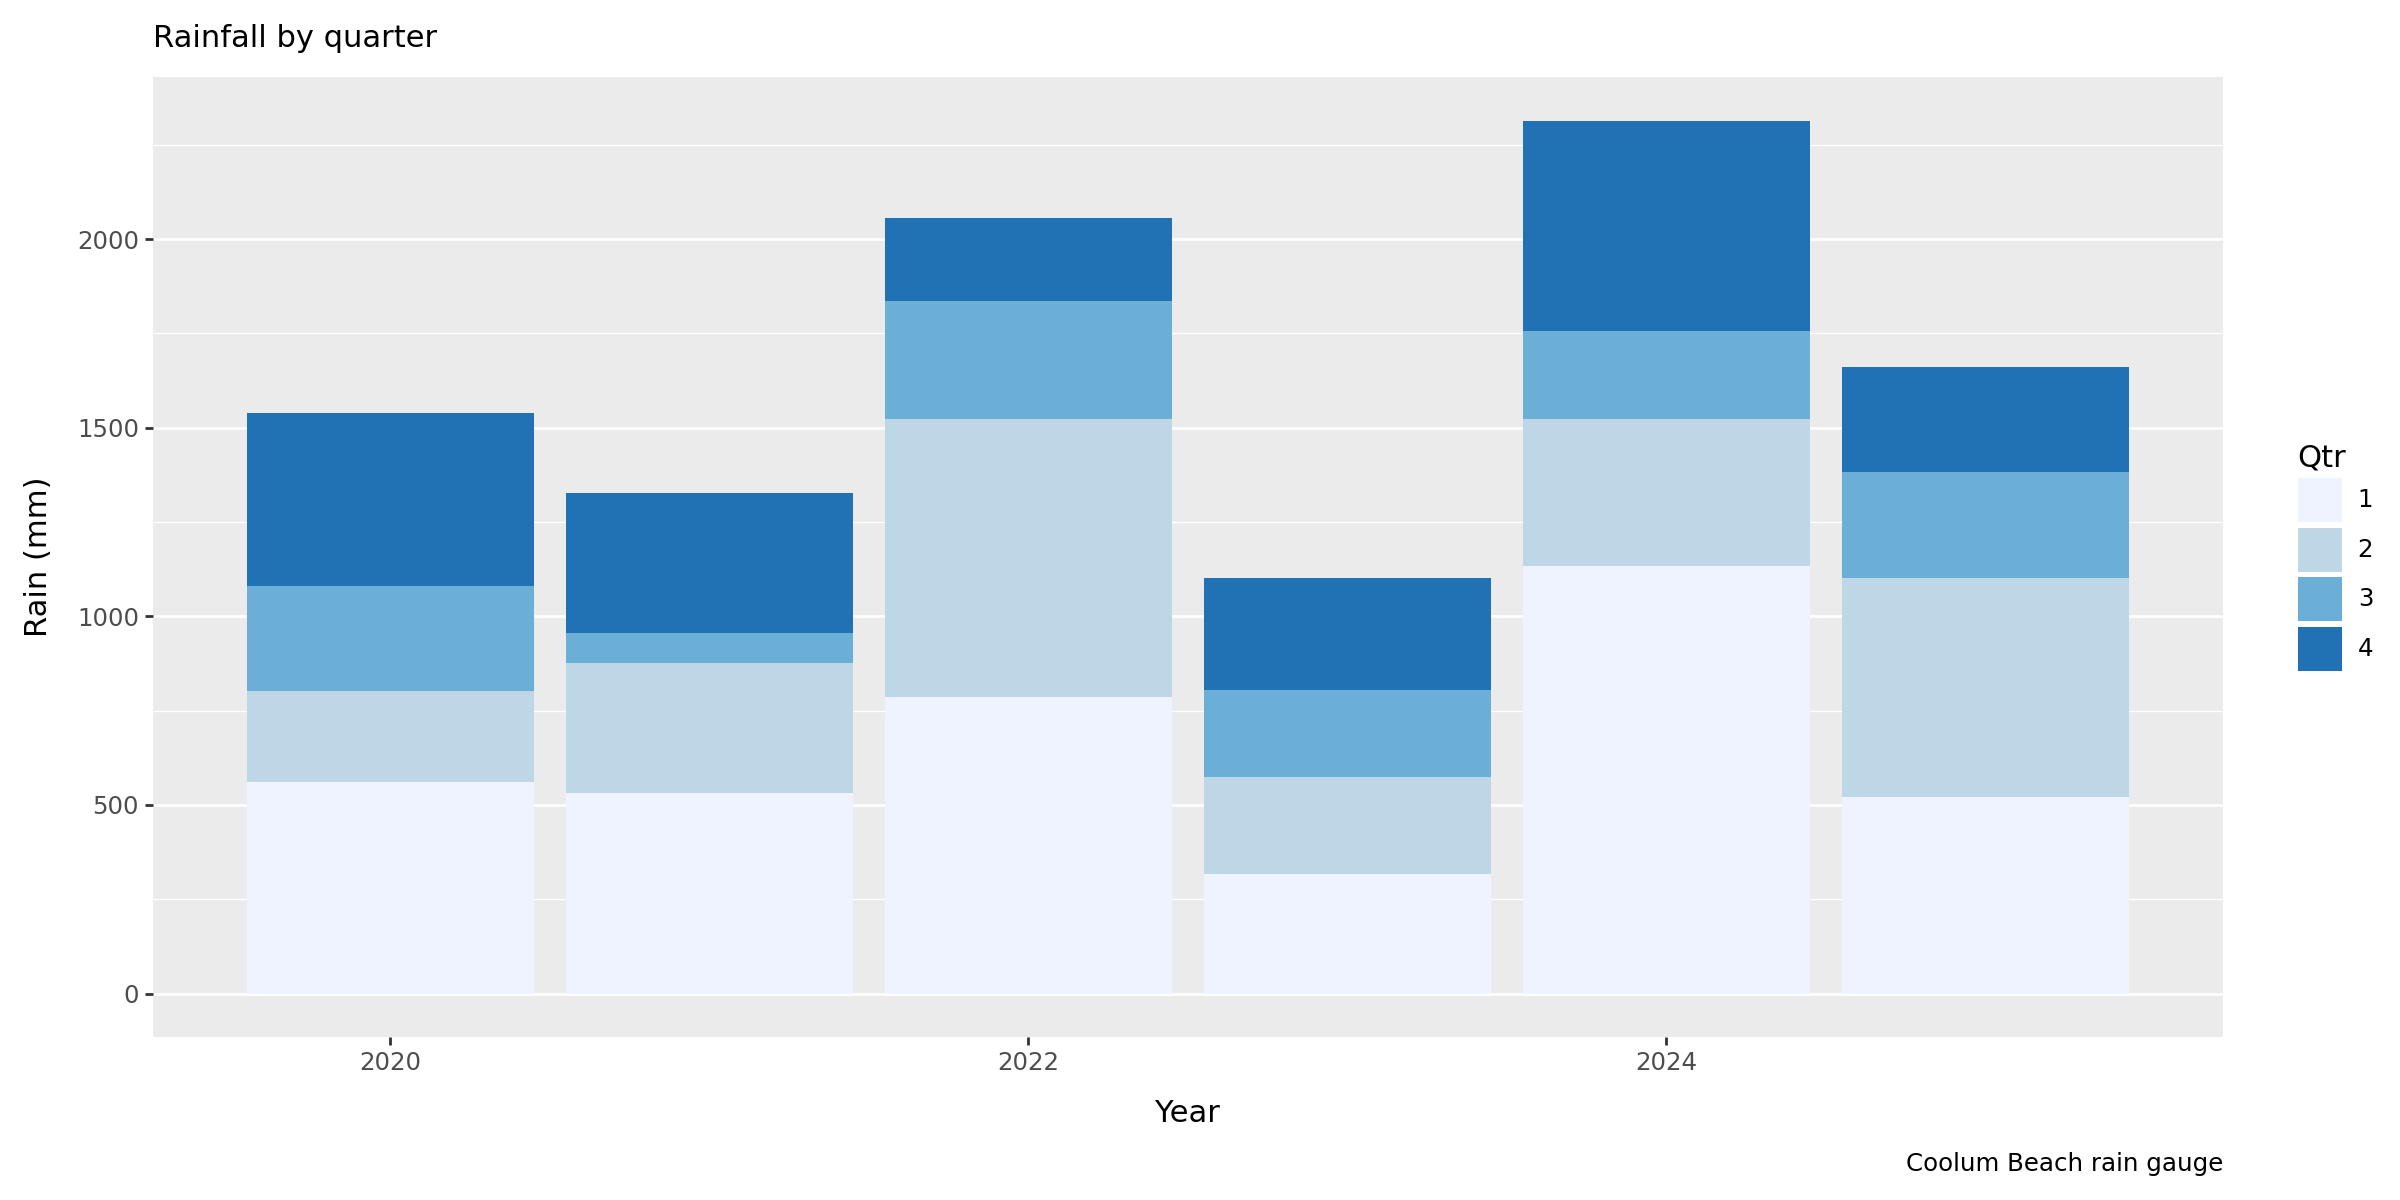

In [33]:
p1 = (
    p9.ggplot(
        data=q_sum_df2,
    )
    + p9.geom_col(
        mapping=p9.aes(
            x='year',
            y='rain',
            fill='factor(qtr)',
        ),
        position=p9.position_stack(reverse=True),
    )
    + p9.scale_fill_brewer(
        type='seq',
        palette='Blues',
    )
)

width = 12
height = 6
(
    p1
    + p9.theme(
        figure_size=(width, height),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
    )
    + labels
)

---------------------
## iPad comparison

The plot to be compared is the plot shown below.  The iPad and Plotnine plots are essentially the same, but I am annoyed because not all year numbers are shown by default in the Plotnine graphic.

I will remedy this in plots to be created further below.  Note that the radar-style plot shown in the iPad gallery is not natively supported by Plotnine.  The top bar chart in the iPad gallery will be re-created in the section below.

![](images/all_qrts_stacked.png)

--------------------

## Show rain by quarter and year, side-by-side columns

We don't change much code.  We change the position parameter to ```dodge```: this places columns that would be overlapping  directly beside one another. 

     "Dodging preserves the vertical position of an geom while adjusting the horizontal position."
Other changes:
+ all columns are set to 0.7 width (smaller the default)
+ all columns have a gray border line (helps the pale blue bars stand out)
+ the x-axis has tick marks and tick labels for all years, via the ```scale_x_continous``` call
+ the theme is changed from default to a Black-White version.  Note the theme call that sets the plot size must come after the ```theme_bw``` call.

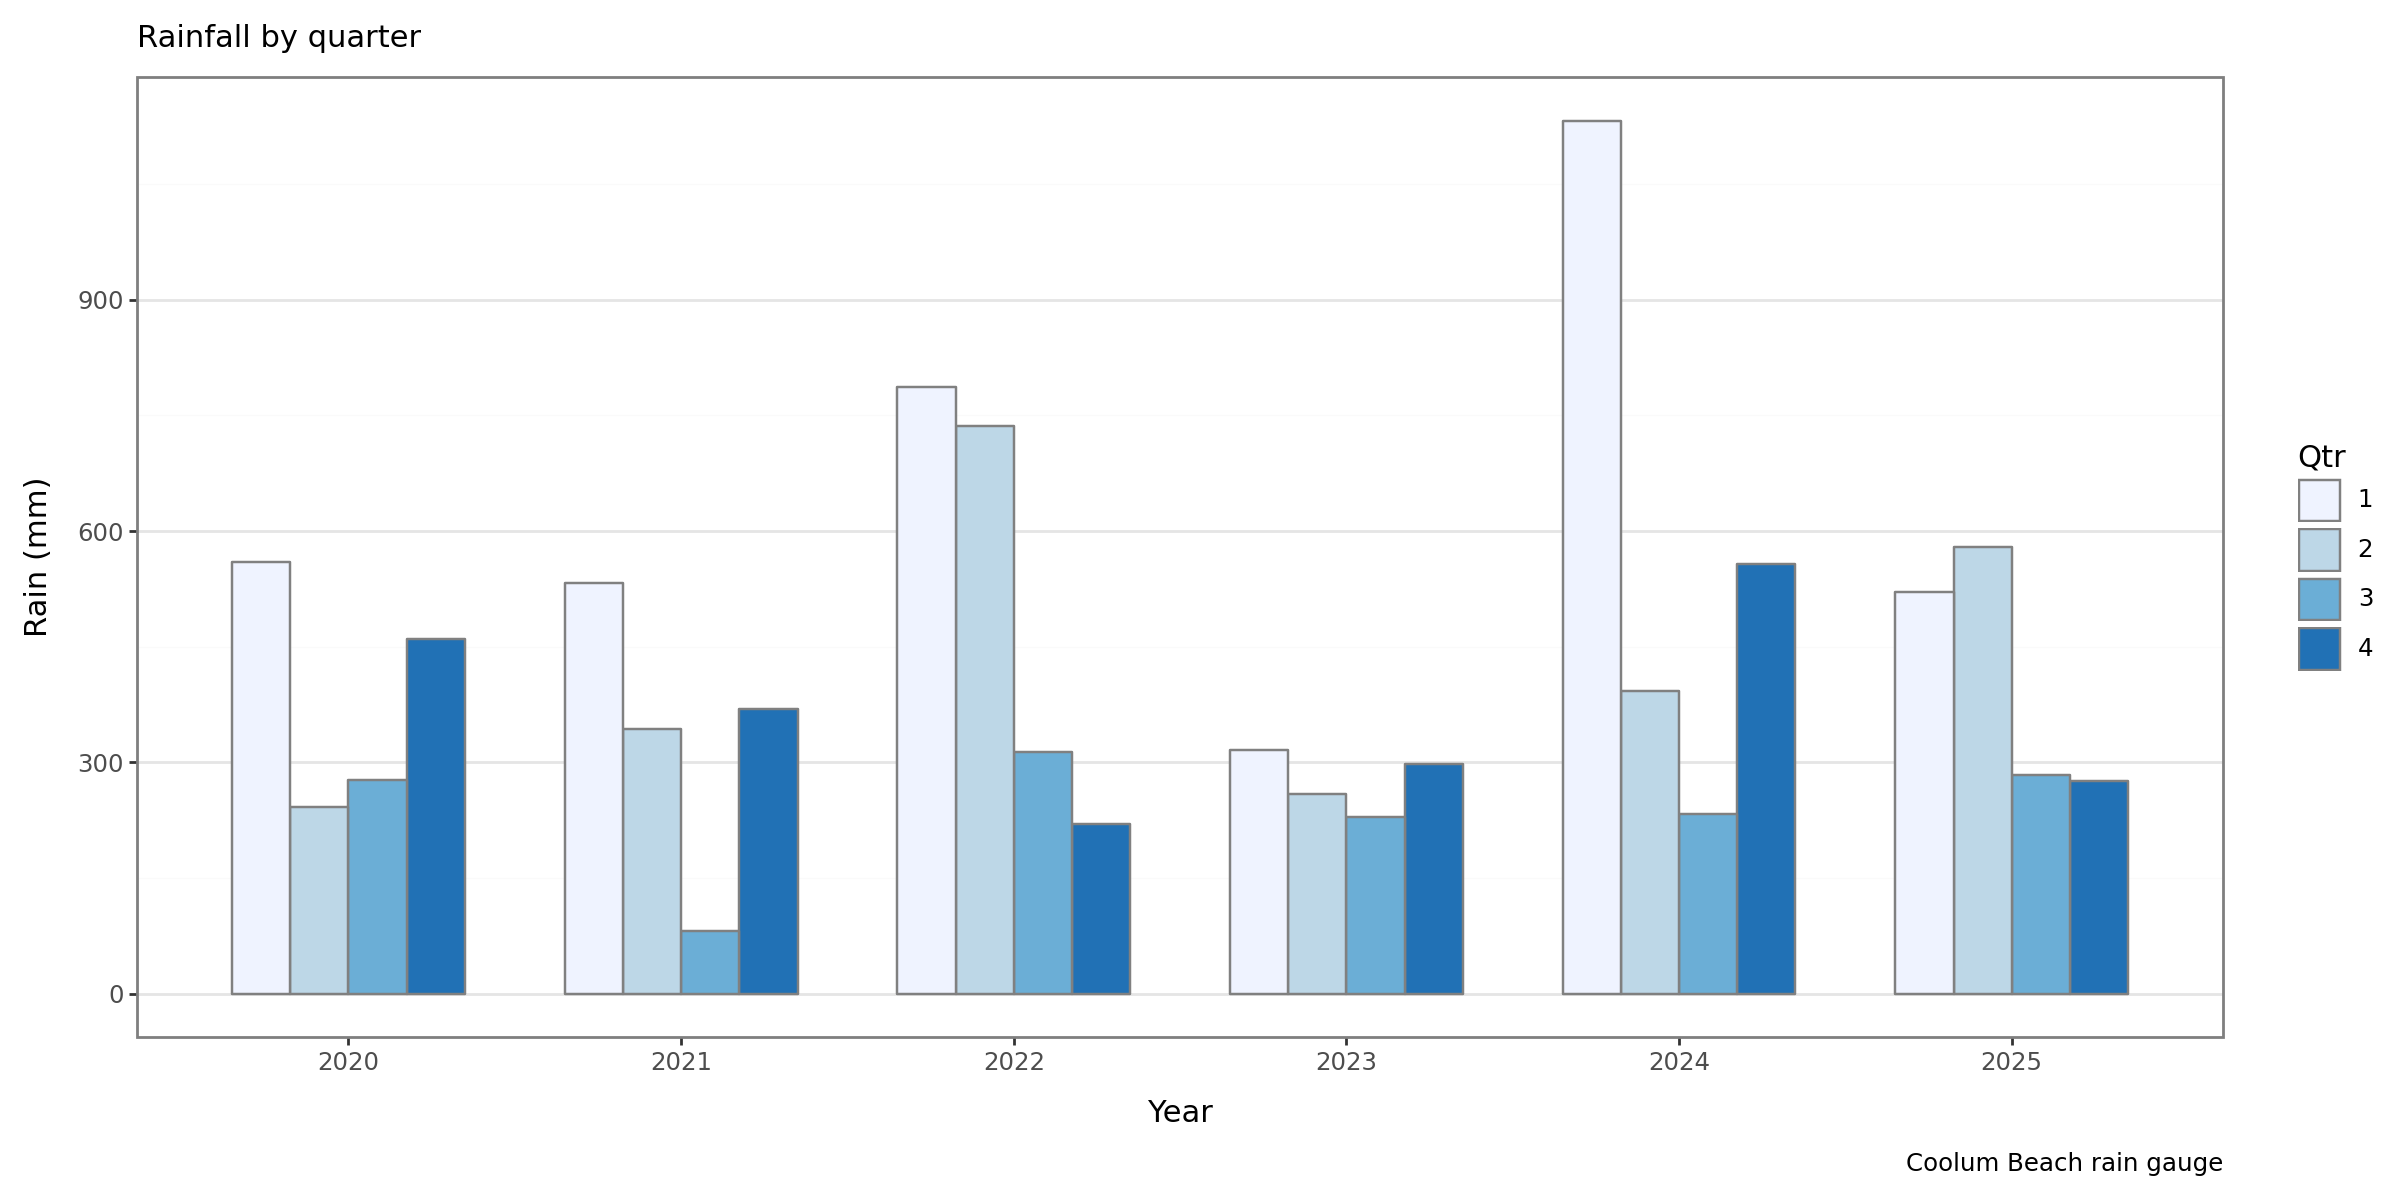

In [34]:
p1 = (
    p9.ggplot(
        data=q_sum_df2,
    )
    + p9.geom_col(
        mapping=p9.aes(
            x='year',
            y='rain',
            fill='factor(qtr)',
        ),
        position='dodge',
        color='gray',
        width=0.7,
    )
    + p9.scale_fill_brewer(
        type='seq',
        palette='Blues',
    )
)

width = 12
height = 6
(
    p1
    + labels
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
    )
    + p9.scale_x_continuous(breaks=list(range(2020, 2026)))
)

-------------------
## Comparison with iPad

I think I prefer the Plotnine version to the iPad version (see below). Interestingly, this is the first plot that starts to show the wet summer / dry winter of the Sunshine Coast climate

![](images/all_qrts_bar.png)

--------------

## Show rain by month, x-axis years

As we did with quarters, we create a new column in our DataFrame that holds the month of each reading (derived from the date column).  We then turn this into a categorical column, and declare the categories to be be ordered.  If we don't, we get month names sorted alphabetically in our plots

In [35]:
rain_df2['month'] = rain_df2['date'].dt.month_name()
months = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December',
]
rain_df2['month'] = (
    rain_df2['month'].astype('str').astype('category')
)
rain_df2['month'] = rain_df2[
    'month'
].cat.reorder_categories(months, ordered=True)

Check the data types: month is a category, as declared

In [36]:
rain_df2.dtypes

date        datetime64[ns]
rain               float64
year                 int32
cum_rain           float64
qtr                  int32
month             category
dtype: object

As before, we use Pandas to group together rows by month, within each year, and sum to give monthly rainfall.  We create a new DataFrame from the groupby object, and reset the index

In [37]:
m_sum = rain_df2.groupby(['month', 'year'], observed=False)[
    'rain'
].sum()

In [38]:
m_sum_df = pd.DataFrame(m_sum)

In [39]:
m_sum_df2 = m_sum_df.reset_index(level=['month', 'year'])

Check the first few rows

In [40]:
m_sum_df2.head(2)

,month,year,rain
0,January,2020,0.0
1,January,2021,129.9


Set the labels and title for this plot, and the fill color legend

In [41]:
labels = p9.labs(
    y='Rain (mm)',
    fill='Month',
    x='Year',
    caption='Coolum Beach rain gauge',
    subtitle='Rainfall by month',
)

We:
+ create a plot object, using our new DataFrame as a data source
+ create a layer containing columns
+ each column has an x-axis position based upon the year
+ each column has a y-axis height based upon the rain value
+ each column is filled with a color based upon the month (treated as a category).  The fill colors will span the full spectrum
+ each colum is positioned beside the other columns (no overlap or stacking)
+ each column has a gray border

The fill palette for the months is set by ```scale_fill_discrete()``, which creates a qualitative color scale with evenly spaced hues.  We turn off vertical gridlines, and create x-axis tick marks and tick labels for all years.

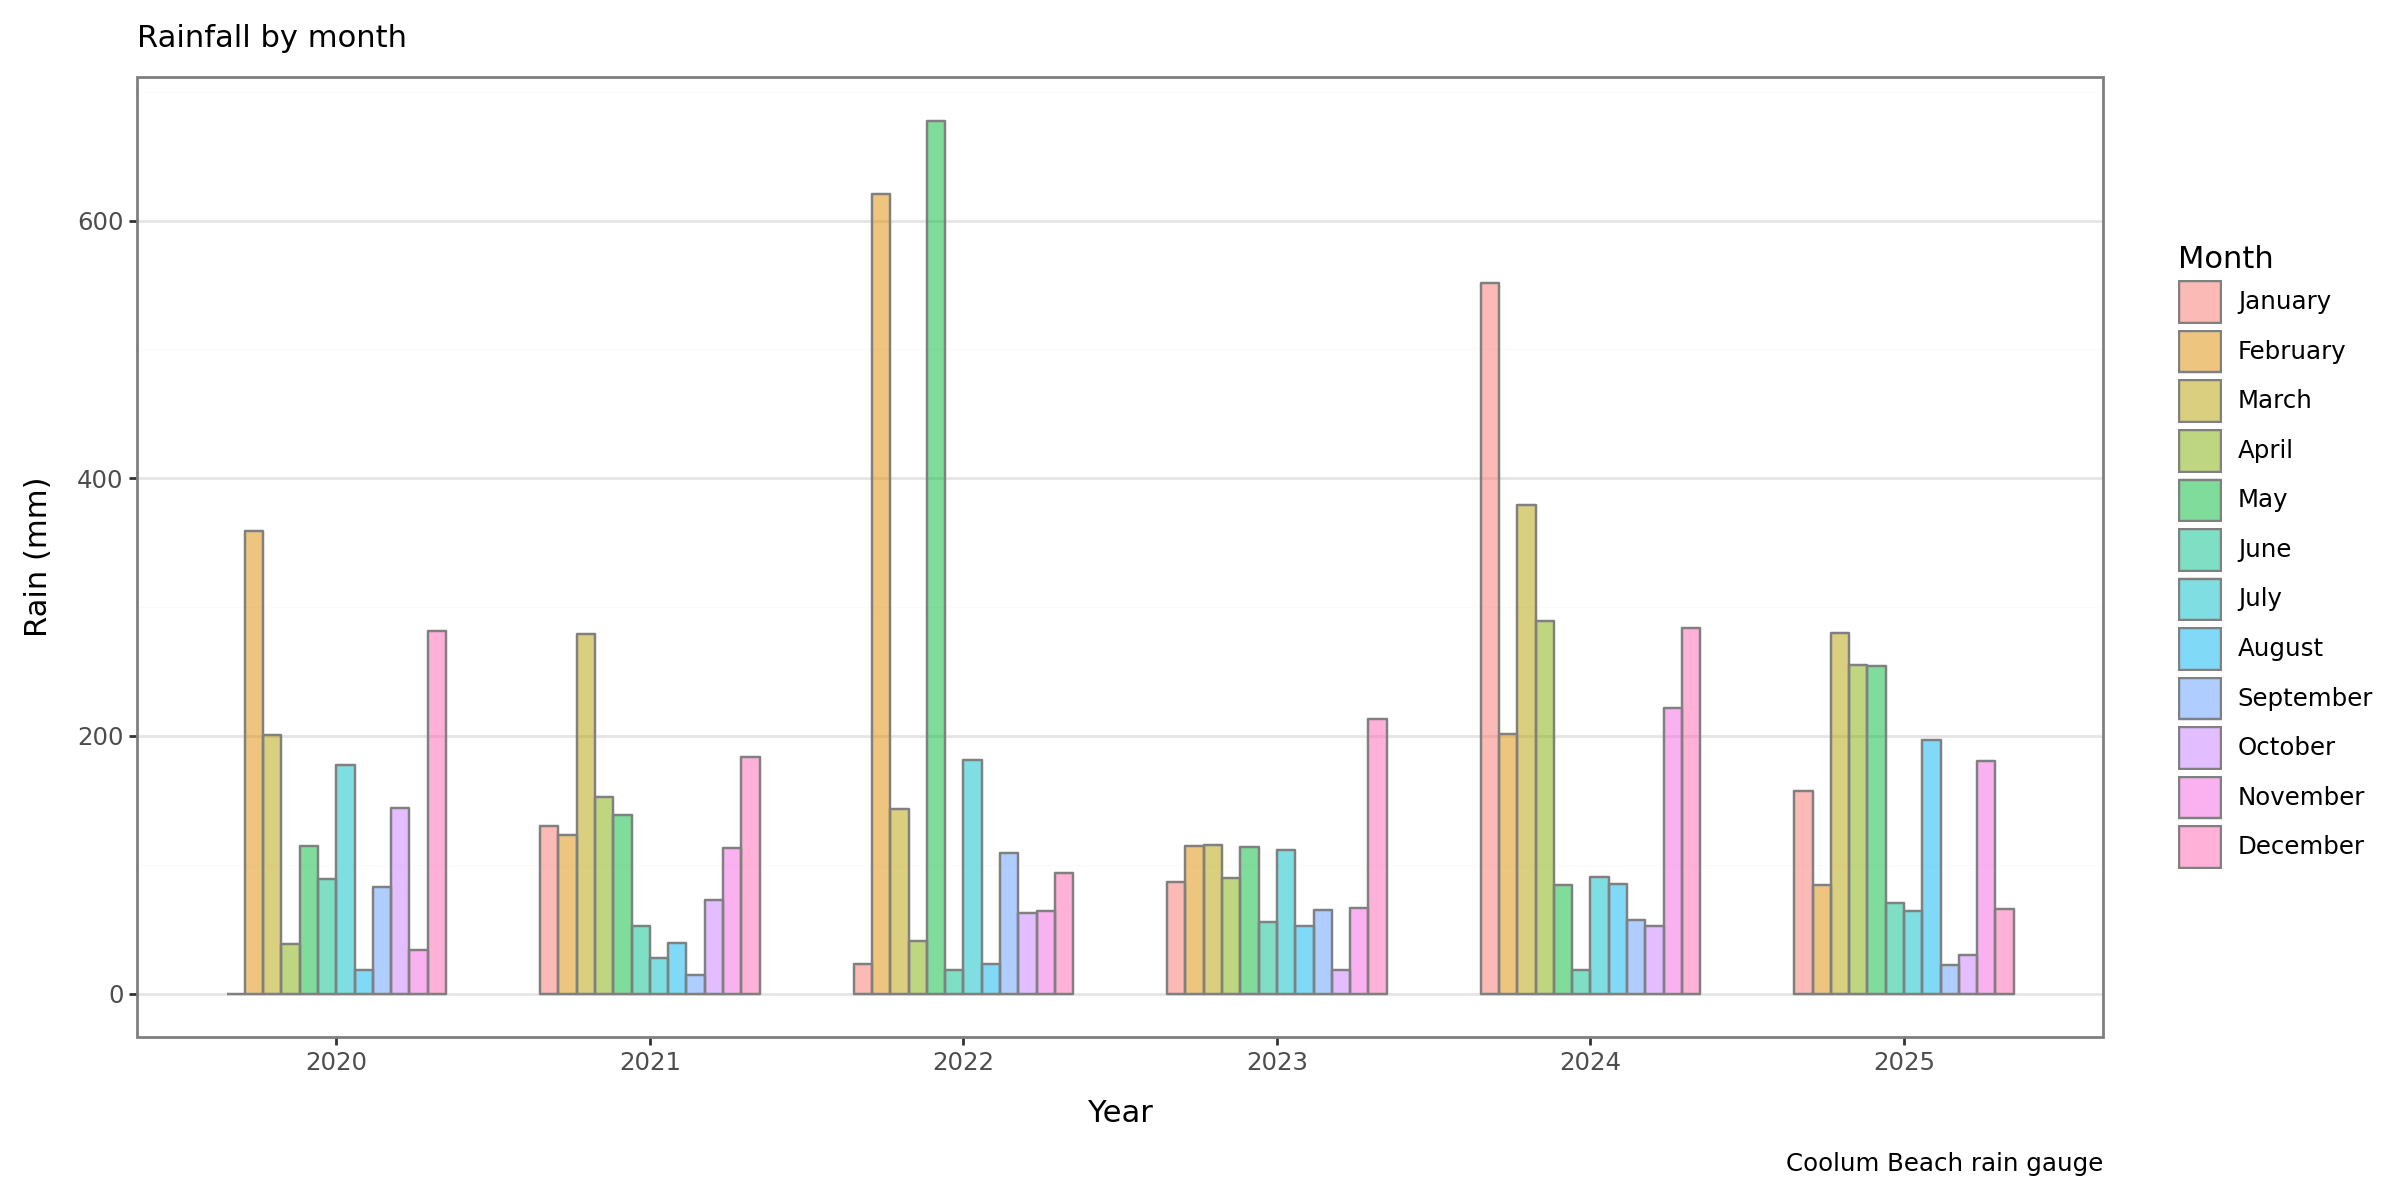

In [42]:
p1 = (
    p9.ggplot(
        data=m_sum_df2,
    )
    + p9.geom_col(
        mapping=p9.aes(
            x='year',
            y='rain',
            fill='factor(month)',
        ),
        position='dodge',
        color='gray',
        width=0.7,
        alpha=0.5,
    )
    + p9.scale_fill_discrete()
)

width = 12
height = 6
(
    p1
    + labels
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
    )
    + p9.scale_x_continuous(breaks=list(range(2020, 2026)))
)

-----------------------
## iPad comparison

I don't have a iPad chart that matches the plot above.  I quite like the feel of the palette, getting warmer at each end of the year.

--------------------
## Show monthly rain, x-axis months

This next plot in a minor inversion of the plot above, except that we show months on the x-axis, and color fill according to year.

Set up labels; we specify that the title of the fill legend should be the text 'Month'.

In [43]:
labels = p9.labs(
    y='Rain (mm)',
    fill='Year',
    x='Month',
    caption='Coolum Beach rain gauge',
    subtitle='Rainfall by month',
)

We:
+ create a plot object, using our summed monthly  DataFrame as a data source
+ create a layer containing columns
+ each column has an x-axis position based upon the month
+ each column has a y-axis height based upon the rain value
+ each column is filled with a color based upon the year (treated as a category)
+ each column is positioned beside the other columns (no overlap or stacking)
+ each column has a gray border

This time, we ask for a fill palette that smoothly runs along a sequence of colors, running from Yellow To Green to Blue, because the years  are an ordered sequence.

Then, as before, we:
+ set the labels
+ set a black and white theme
+ set the plot size via a theme call
+ turn off (set to blank)  vertical gridlines,  in the same theme call

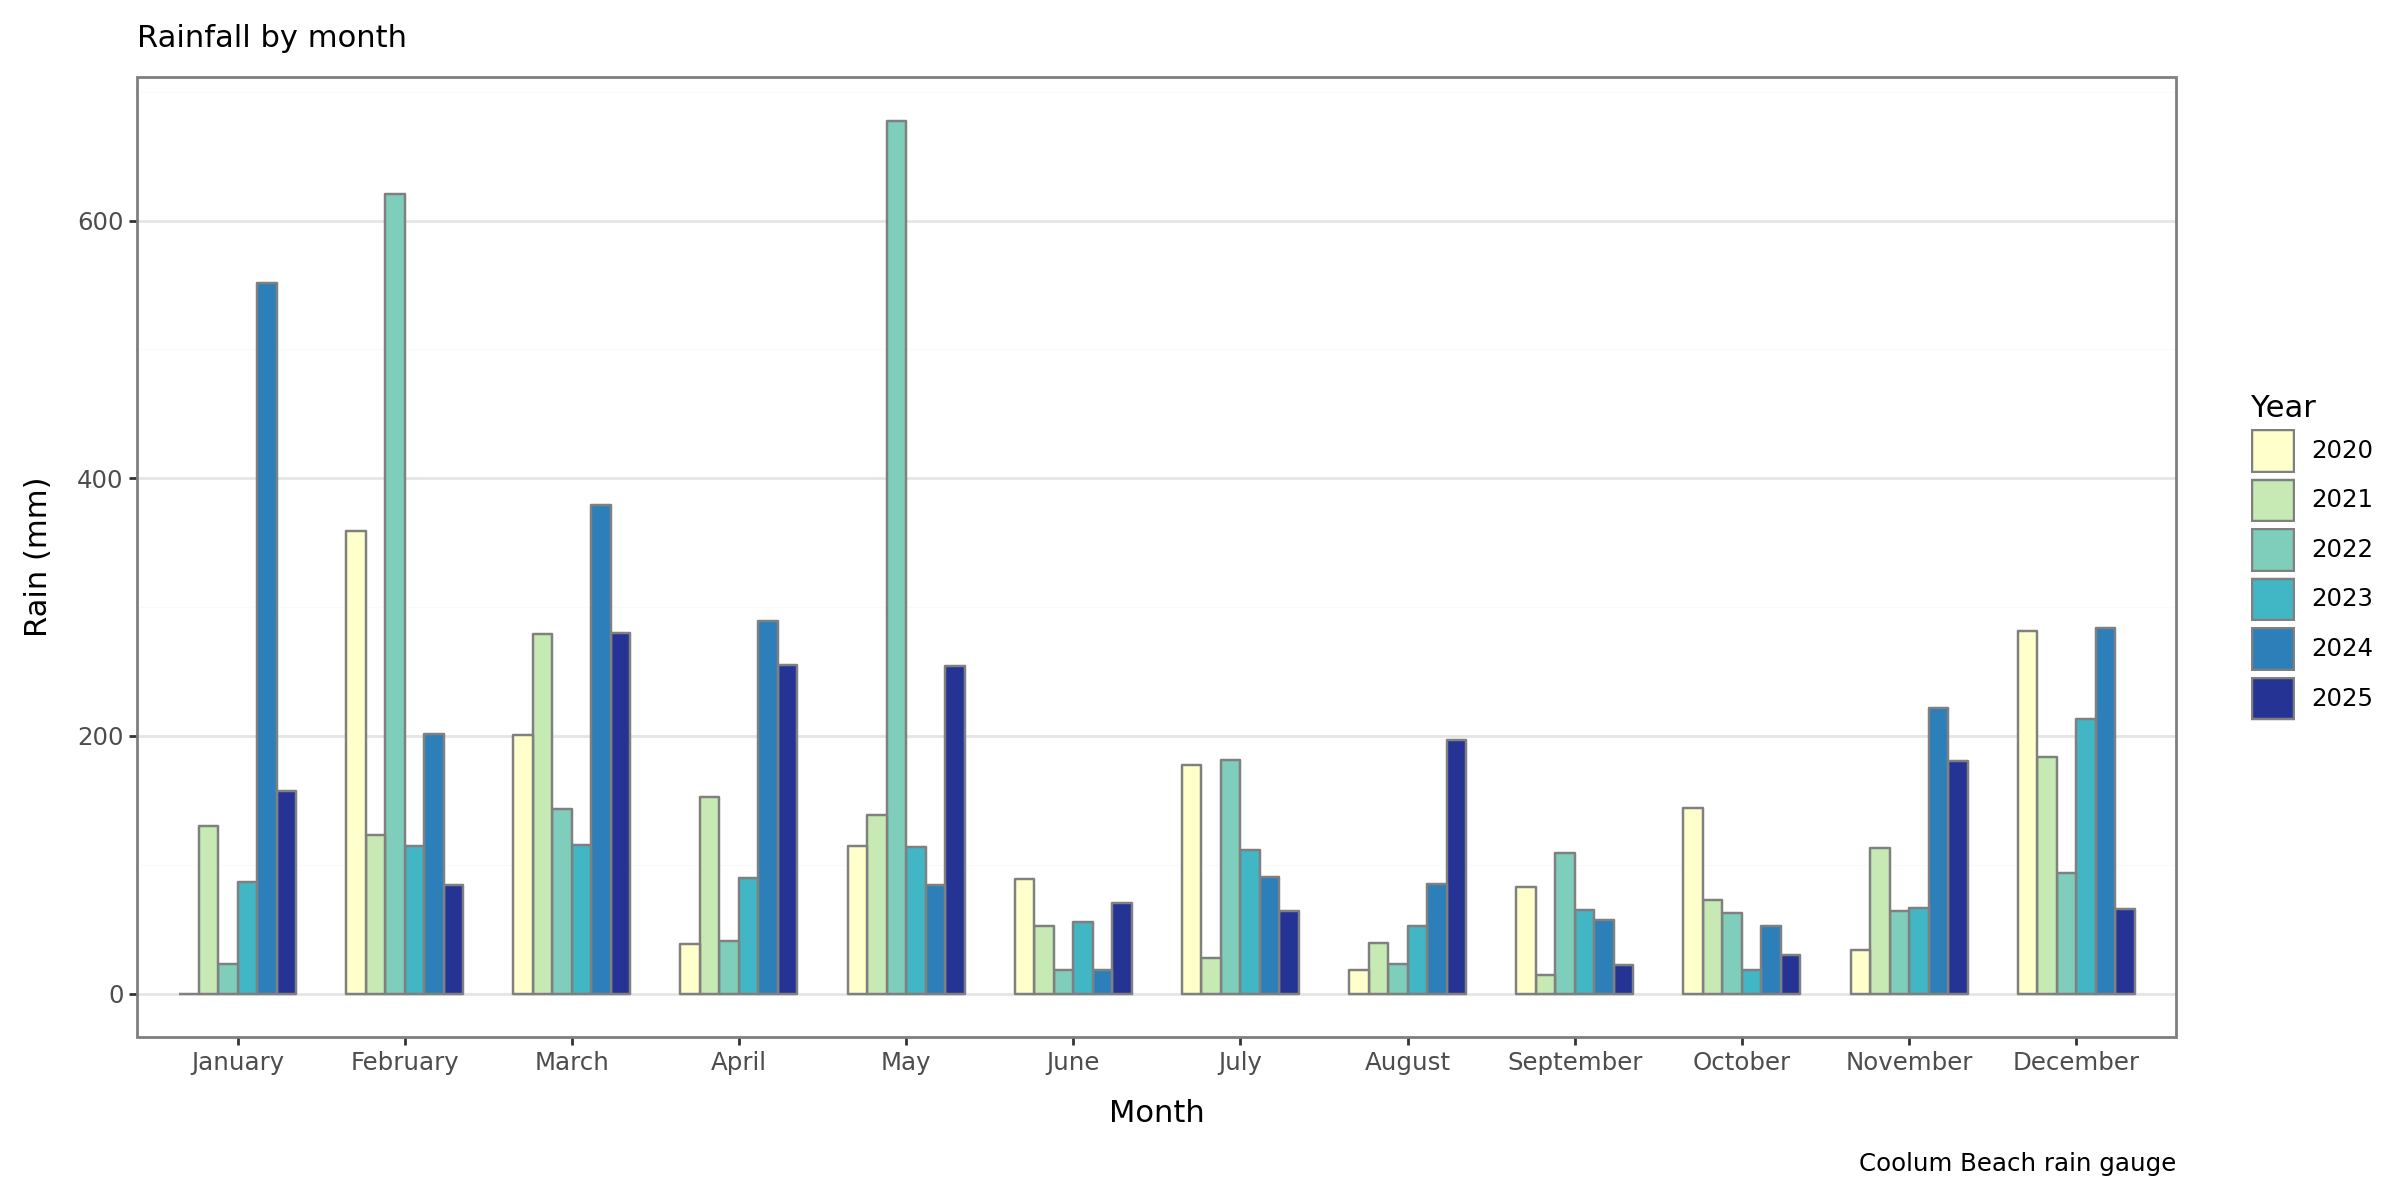

In [44]:
p1 = (
    p9.ggplot(
        data=m_sum_df2,
    )
    + p9.geom_col(
        mapping=p9.aes(
            x='month',
            y='rain',
            fill='factor(year)',
        ),
        position='dodge',
        color='gray',
        width=0.7,
    )
    + p9.scale_fill_brewer(
        type='seq',
        palette='YlGnBu',
    )
)

width = 12
height = 6
(
    p1
    + labels
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
    )
)

----------------

## iPad comparison

The plot above should be compared to the plot below.  I prefer the Plotnine plot: it seems more organised, and less random.  The iPad version seems garish by comparison

![](images/monthly_bar.png)


-----------------------
##  Multiple mini-plots of monthly rain by year

In the iPad gallery below, we have an array of mini-plots (one for each year) showing monthly rainfall.

There are two ways the create the equivalent with Plotnine.  The first is to create an array of plot object and manually lay them out.  The second is to use ```fact_wrap```.

Review first few rows of our summary DataFrame

In [45]:
m_sum_df2.head()

,month,year,rain
0,January,2020,0.0
1,January,2021,129.9
2,January,2022,23.0
3,January,2023,86.5
4,January,2024,551.4


Create short names for months, to make for more elegant plots (no overlapping, all names the same length)

In [46]:
short = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

For each year, we create a plot object:

+ define the labels and titles
+ create an empty plot using our monthly summary DataFrame as the data source
+ add a layer of columns, mapping x-axis position to month, and the column height to rain
+ declare the columns be _not_ stacked, but side by side (in this case, we only have one column for each x-axis value, so this could be considered to be redundant, but maybe good practice to declare the positioning rules explicitly)
+ set each column to be filled with light blue
+ set the y-axis limits for each plot to be the same
+ set the labels to use on the x-axis tick marks
+ set the theme to be a pre-defined black-white
+ set the plot size, and rotate x-axis tick mark labels to prevent overlaps

Finally, take out 6 plot objects (in a list), and manually set them up in two rows of three coluns.

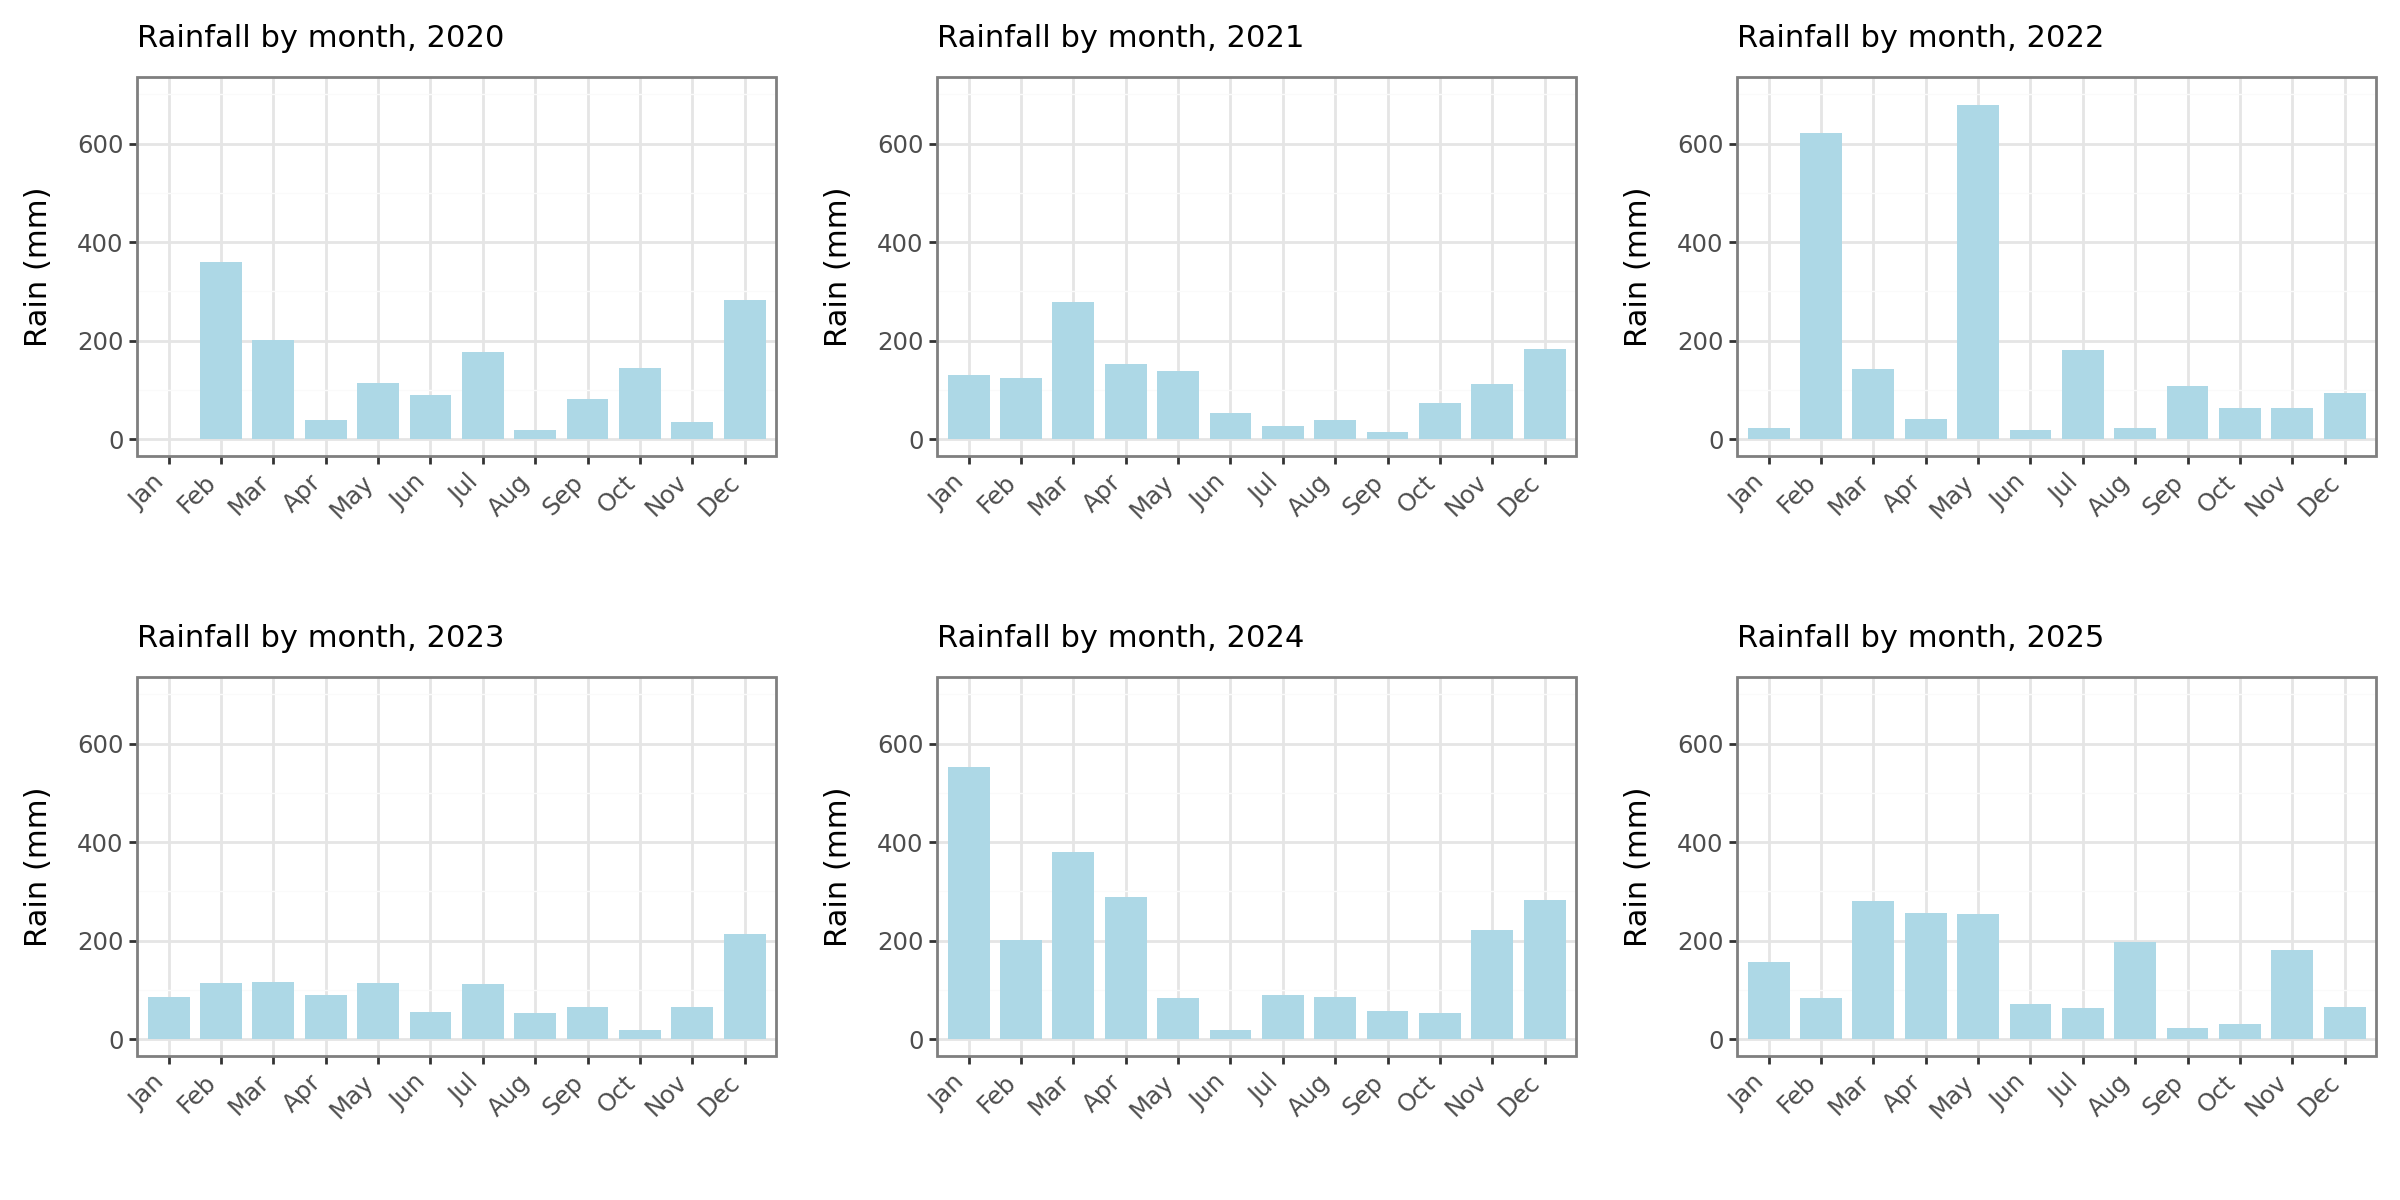

In [47]:
plots = []
for y in range(2020, 2026):
    labels = p9.labs(
        y='Rain (mm)',
        x=' ',
        subtitle=f'Rainfall by month, {y}',
    )
    p1 = (
        p9.ggplot(data=m_sum_df2[m_sum_df2['year'] == y])
        + p9.geom_col(
            mapping=p9.aes(
                x='month',
                y='rain',
            ),
            position='dodge',
            width=0.8,
            fill='lightblue',
        )
        + p9.ylim((0, 700))
        + p9.scale_x_discrete(labels=short)
        + p9.theme_bw()
        + p9.theme(
            figure_size=(width, height),
            axis_text_x=p9.element_text(angle=45, hjust=1),
        )
        + labels
    )
    plots.append(p1)
# end for
(plots[0] | plots[1] | plots[2]) / (
    plots[3] | plots[4] | plots[5]
)

A more elegant way to do this is to declare via a ```facet_wrap``` call, that we want as many subplots as there are years, with a three column layout.

The result is much neater than the manual layout approach, and (in my opinion) clearly superior to the iPad graphic (shown below)

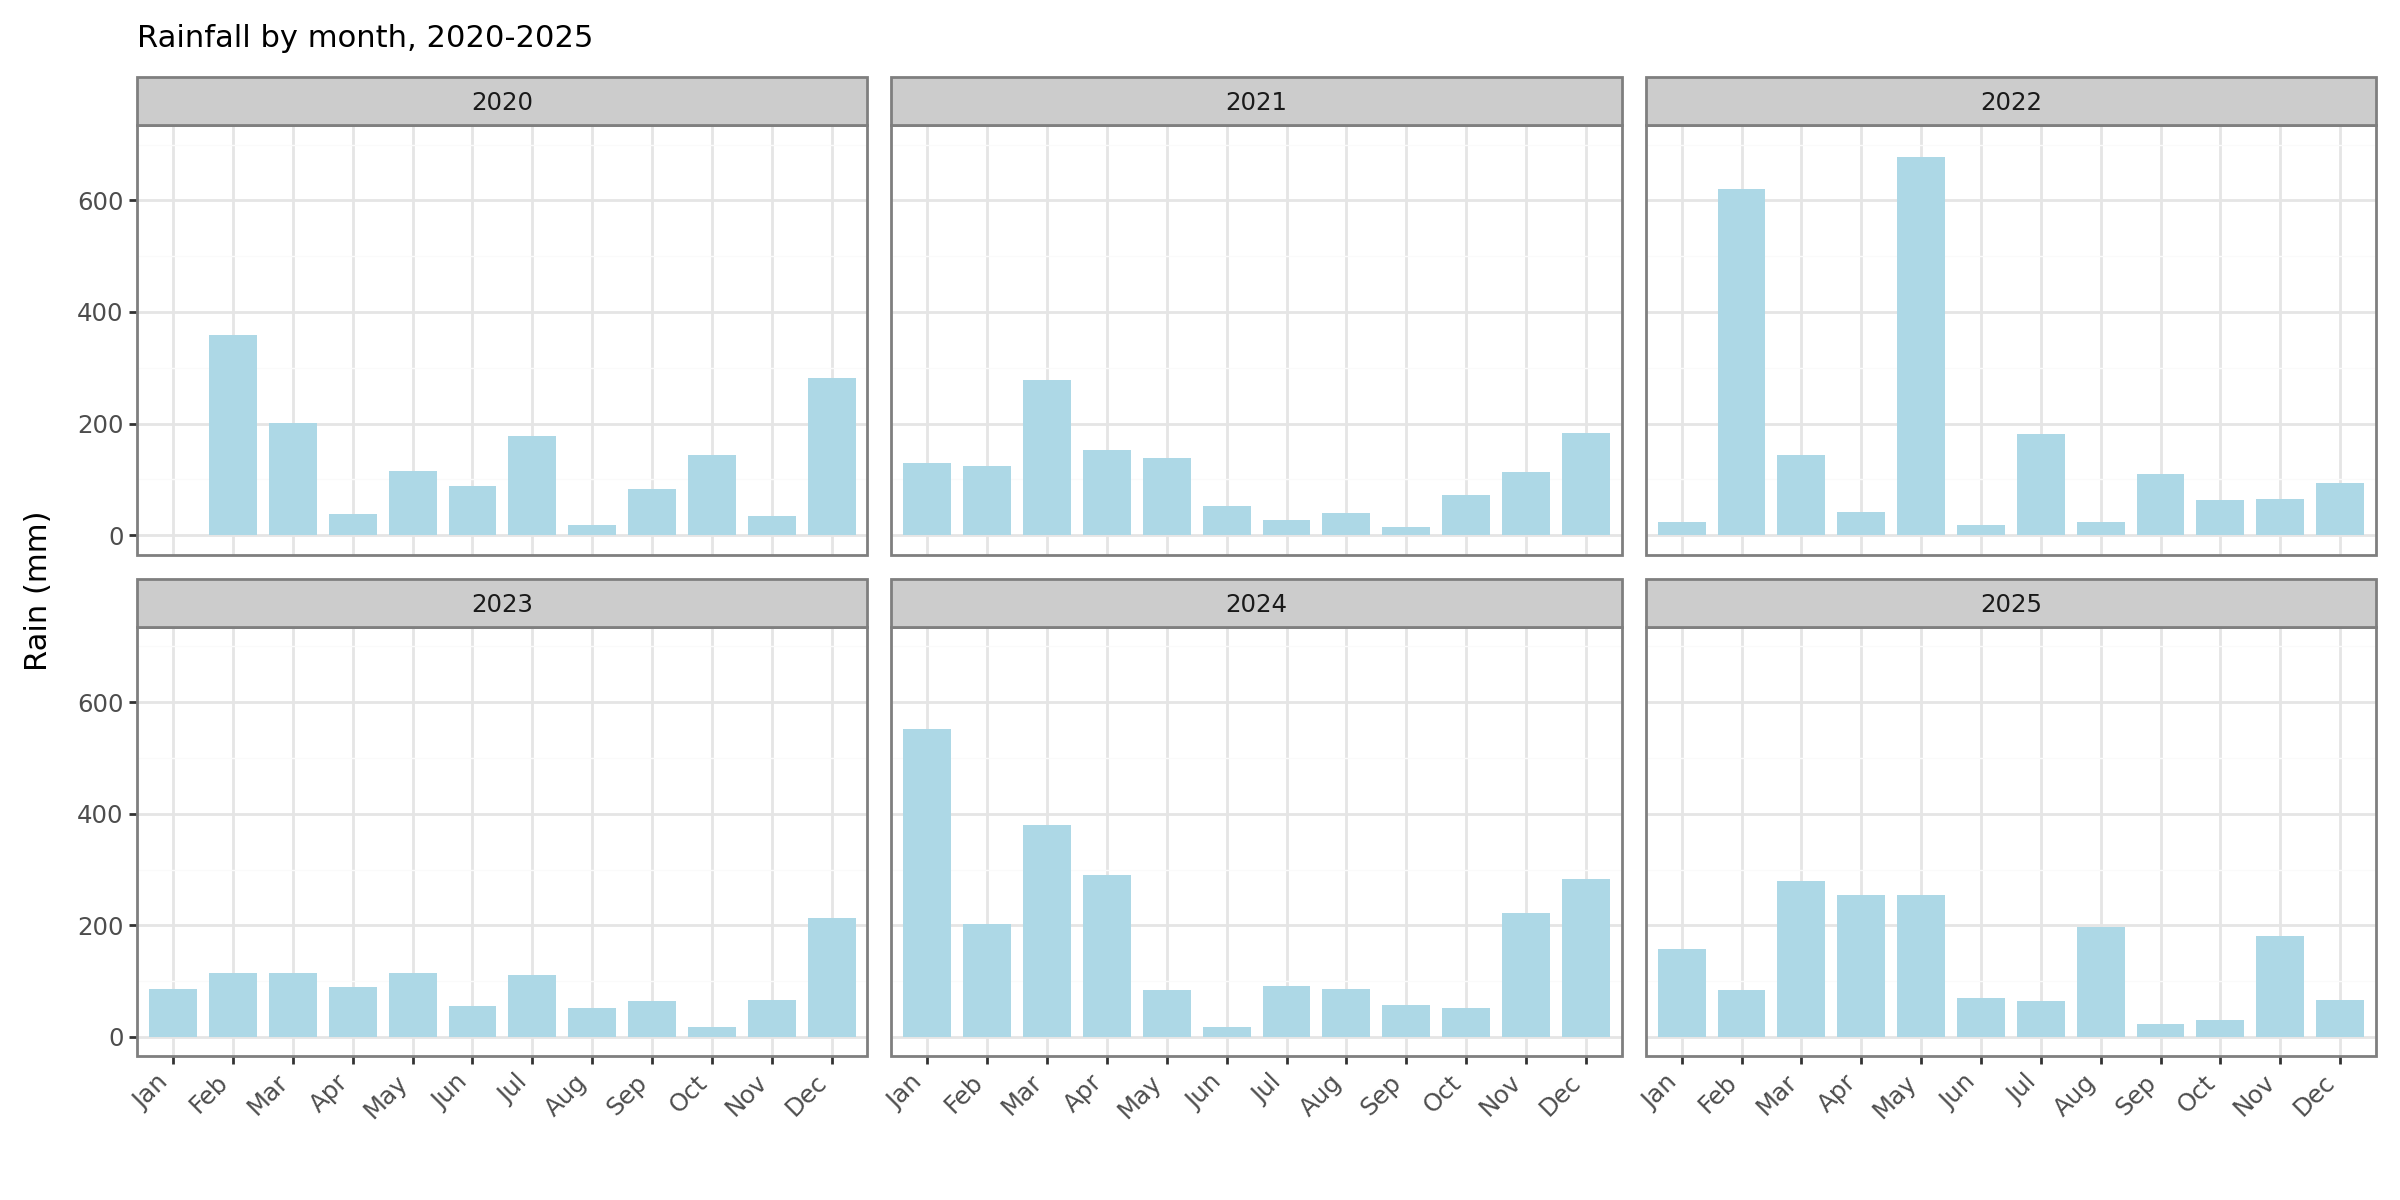

In [48]:
labels = p9.labs(
    y='Rain (mm)',
    x=' ',
    subtitle=f'Rainfall by month, 2020-2025',
)


p1 = (
    p9.ggplot(data=m_sum_df2)
    + p9.geom_col(
        mapping=p9.aes(
            x='month',
            y='rain',
        ),
        position='dodge',
        width=0.8,
        fill='lightblue',
    )
    + p9.ylim((0, 700))
    + p9.scale_x_discrete(labels=short)
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
        axis_text_x=p9.element_text(angle=45, hjust=1),
    )
    + labels
    + p9.facet_wrap(
        'year', ncol=3
    )  # multiple mini-plot magic happens here
)
p1

## iPad comparison

The plot above should be compared to the plot below.  I prefer the Plotnine plot: it seems more organised, and less random.  The iPad version seems garish by comparison

![](images/monthly_mini.png)

-------------------------------

## Show monthly statistics

We now create some graphics that aggregate monthly rainfall data across all years, showing minimum, average, and maximum rainfall for each month.

We use Pandas to group rows by year and month with year, and sum the rain values for each group, and review the resulting DataFrame.

In [49]:
rain_df2.head()

,date,rain,year,cum_rain,qtr,month
0,2020-01-01,0.0,2020,0.0,1,January
1,2020-01-02,0.0,2020,0.0,1,January
2,2020-01-03,0.0,2020,0.0,1,January
3,2020-01-04,0.0,2020,0.0,1,January
4,2020-01-05,0.0,2020,0.0,1,January


In [50]:
m_rain = (
    rain_df2[['rain', 'year', 'month']]
    .groupby(['year', 'month'], observed=False)
    .sum()
    .reset_index(level=['month', 'year'])
)
m_rain

,year,month,rain
0,2020,January,0.0
1,2020,February,359.0
2,2020,March,201.0
3,2020,April,38.4
4,2020,May,114.6
...,...,...,...
67,2025,August,196.5
68,2025,September,22.5
69,2025,October,30.0
70,2025,November,180.8


### Create statistics dataframe

We now create a new DataFrame with three columns holding the minimum, average and maximum for each month, over all years.  This is not in the spirt of long DataFrames, but because we pour each column into a separate plot, it doesn't matter.

In [51]:
m_max = []
m_min = []
m_avg = []

for m in months:
    v_max = m_rain[m_rain['month'] == m]['rain'].max()
    v_min = m_rain[m_rain['month'] == m]['rain'].min()
    v_avg = m_rain[m_rain['month'] == m]['rain'].mean()

    m_max.append(v_max)
    m_min.append(v_min)
    m_avg.append(v_avg)
# end for

m_stats_df = pd.DataFrame(
    {
        'month': months,
        'min': m_min,
        'avg': m_avg,
        'max': m_max,
    }
)

In order to create Plotnine plots in the style we want, we specify that month is a category, and has a sort-order that is __not__ alphabetic

In [52]:
m_stats_df['month'] = (
    m_stats_df['month'].astype('str').astype('category')
)
m_stats_df['month'] = m_stats_df[
    'month'
].cat.reorder_categories(
    list(reversed(months)), ordered=True
)

Review the first few rows of the statistics dataframe

In [53]:
m_stats_df.head()

,month,min,avg,max
0,January,0.0,157.966667,551.4
1,February,84.0,250.533333,620.5
2,March,115.2,232.983333,379.4
3,April,38.4,144.333333,289.4
4,May,84.5,230.516667,677.5


### Loop to create plots

Because I have chosen to capture summary statistics in a multi-column DataFrame (one column for each statistic), I can't use the Plotnine facet_wrap functions.  That's OK, because I want to have a seperate title for each subplot.  

Set up lists holding the Plotnine label objects, column names, and fill color alpha.  We have the minimum rain very light blue, and the heaviest rain darkest blue.

In [54]:
label_min = p9.labs(
    y='Rain (mm)',
    x=' ',
    caption='Coolum Beach rain gauge (2020-2025)',
    subtitle='Lowest monthly rain',
)
label_max = p9.labs(
    y='Rain (mm)',
    x=' ',
    caption='Coolum Beach rain gauge (2020-2025)',
    subtitle='Highest monthly rain',
)
label_avg = p9.labs(
    y='Rain (mm)',
    x=' ',
    caption='Coolum Beach rain gauge (2020-2025)',
    subtitle='Average monthly rain',
)
labels = [label_min, label_avg, label_max]
col_names = ['min', 'avg', 'max']
alphas = [0.5, 0.7, 1.0]

Loop to create three sub-plots (stored in a list), one for each statistic.  In order to nicely plot month names, we flip the chart to put the x-axis vertical, and the y-axis horizontal.

In [55]:
plots = []

for name, label, a in zip(col_names, labels, alphas):
    p1 = (
        p9.ggplot(data=m_stats_df)
        + p9.geom_col(
            mapping=p9.aes(y=name, x='month'),
            fill='lightblue',
            alpha=a,
        )
        + p9.coord_flip()  # flip the chart - x-axis vertical
        + p9.ylim(
            (0, 800)
        )  # limits of (now flipped) y-axis
        + label
        + p9.theme_bw()
        + p9.theme(
            figure_size=(width, height),
            panel_grid_major_y=p9.element_blank(),  # turn off gridlines for months
            panel_grid_minor_y=p9.element_blank(),
        )
    )
    plots.append(p1)
# end for

### Layout sub-plots
Plot the three sub-plots side by side

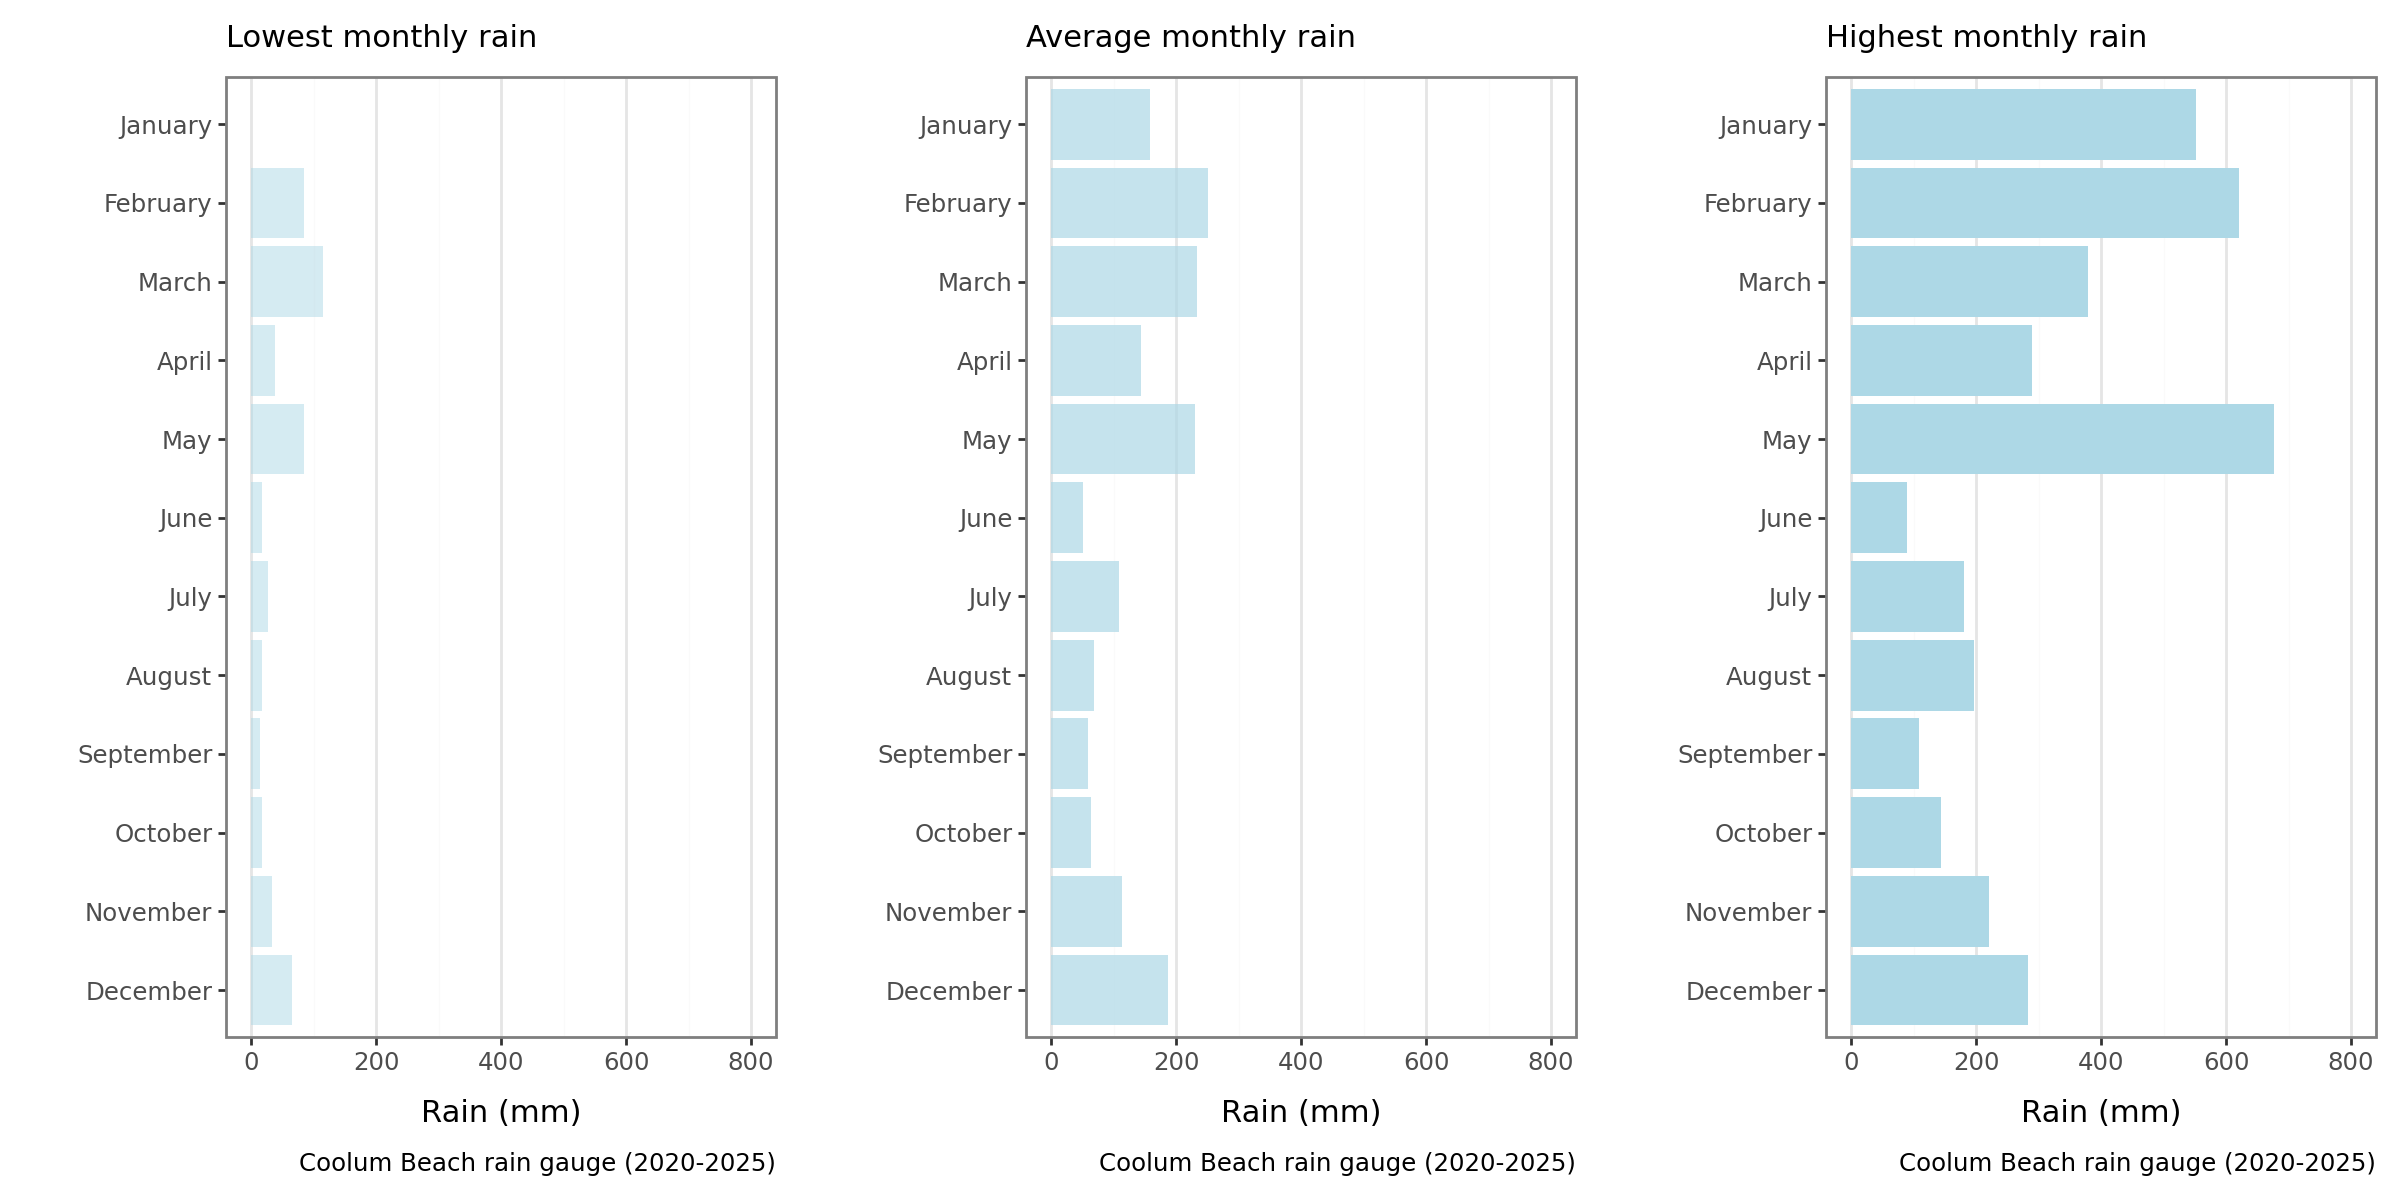

In [56]:
(plots[0] | plots[1] | plots[2])

-----------------------------
## iPad comparison

The comparable iPad chart is shown below.  I prefer the Plotnine version.

![](images/month_stats.png)

----------------------------

## Yearly totals

To show the chart of yearly totals, we use Pandas to group rows by year, and sum each group.  We want a vertical bar chart, with the value of each years rainfall above the bar.  

Review the first few rows of the rainfall DataFrame

In [57]:
rain_df2[['date', 'rain']].head()

,date,rain
0,2020-01-01,0.0
1,2020-01-02,0.0
2,2020-01-03,0.0
3,2020-01-04,0.0
4,2020-01-05,0.0


Use Pandas to group and sum to give rearly totals, and review the result

In [58]:
y_rain_df = (
    rain_df2[['rain', 'year']]
    .groupby(
        'year',
        observed=False,
    )
    .sum()
    .reset_index(level=['year'])
)
y_rain_df

,year,rain
0,2020,1539.2
1,2021,1327.0
2,2022,2056.7
3,2023,1101.9
4,2024,2314.2
5,2025,1660.1


### Plot yearly totals

#### Labels

We define the labels
we want for our chart

In [59]:
labels = p9.labs(
    y='Rain (mm)',
    x=' ',
    caption='Coolum Beach rain gauge',
    subtitle='Rainfall by year',
)

#### Text
We specify that we want a layer of text labels above our bars, based upon the value in the ```rain``` column (rounded to an integer).  Note that this ```goem_text``` call is unaware of the data source holding the __rain__, and __year__ columns.  When this object is glued to the plot object created by the __ggplot__ call, then it will build the text labels.

In [60]:
value_text = p9.geom_text(
    p9.aes(label="rain", x='year', y='rain'),
    size=8,
    va="bottom",  # align bottom of text to be at y value
    format_string="{:,.0f}",  # dont show digits after decimal point (round to integer), put in comma between three digit groups
)

Create our plot:

+ create an empty plot, specifying our data source
+ add a layer of vertical columns, position on x-axis related to year, height related to rain
+ fill the columns with a light blue fill
+ set the columns to almost opaque (alpha value)
+ add the layer of text labels, as specified earlier
+ set the overall theme to be black and white
+ perform a them call to set:
   + plot size
   + suppress vertical gridlines
   + set subtitle text centered
+ add labels

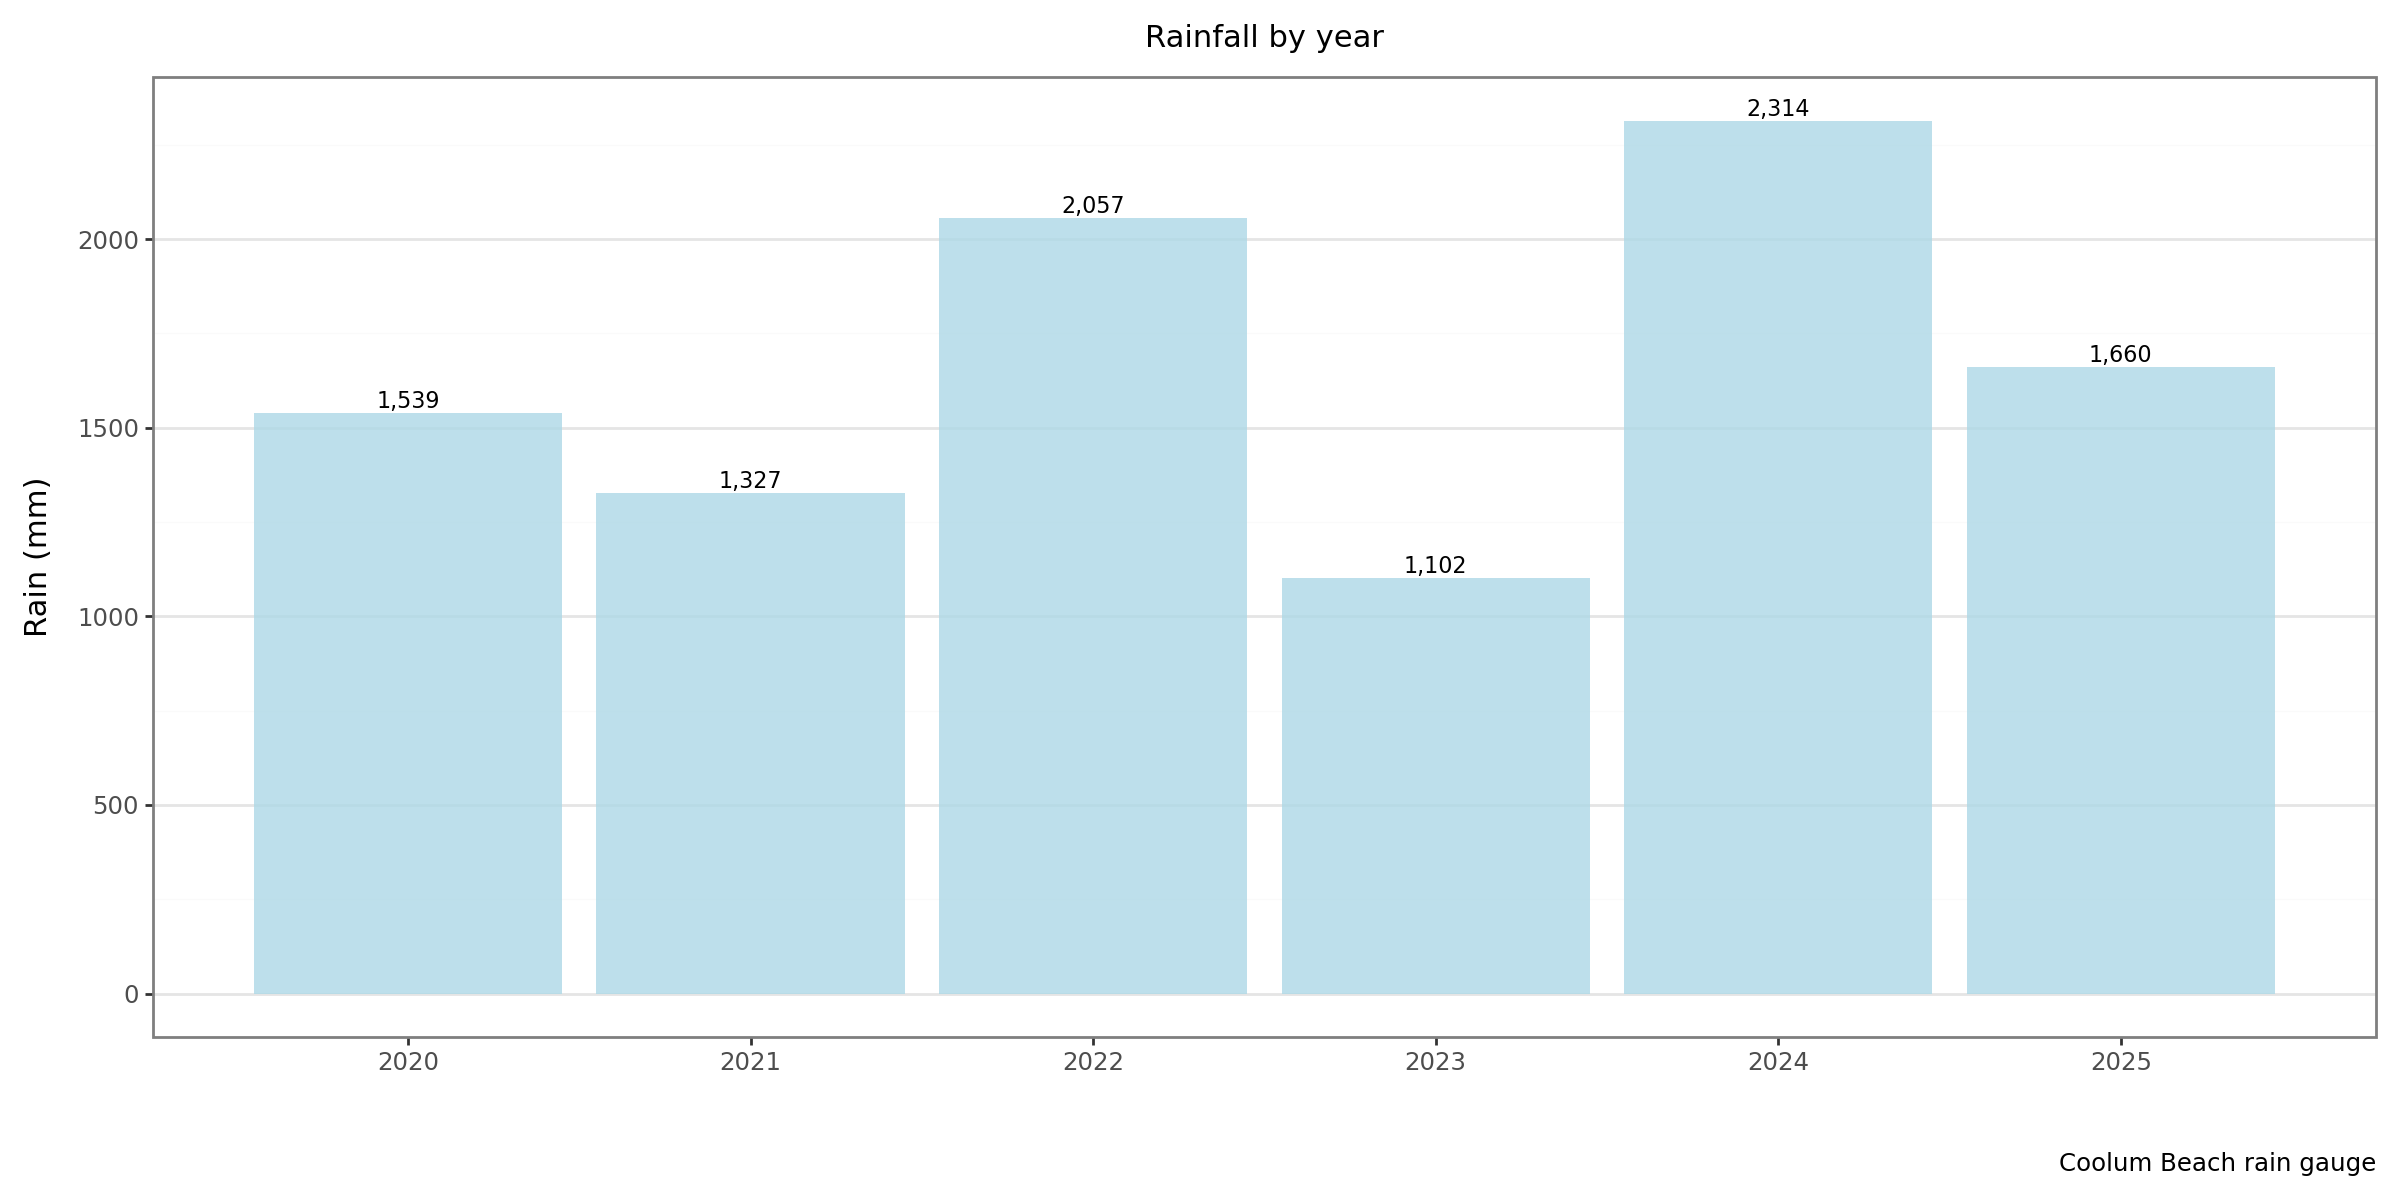

In [61]:
p1 = (
    p9.ggplot(data=y_rain_df)
    + p9.geom_col(
        mapping=p9.aes(x='year', y='rain'),
        fill='lightblue',
        alpha=0.8,
    )
    + value_text  # add text layer
    + p9.theme_bw()
    + p9.theme(
        figure_size=(width, height),
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor_x=p9.element_blank(),
        plot_subtitle=p9.element_text(ha='center'),
    )
    + p9.scale_x_continuous(breaks=list(range(2020, 2026)))
    + labels
)
p1

-----------------------------
## iPad comparison

The comparable iPad chart is shown below.  I prefer the Plotnine version, although showing yearly rainfall as a barrel of water initially did appleal to me

![](images/yearly.png)

-----------------------

## Conclusions


I initially didn't appreciate Plotnine, because I hadn't put in the hard yards to understand the underlying concepts.  Now I have a better grasp of how to use it, it is now my go-to plotting and charting tool.  It is missing a few features I sometimes use (like two y-axis graphs), and some of the specialized charts Seaborn can produce (like marginal distribution plots)

----------------------

## Reproducability

In [62]:
%watermark

Last updated: 2026-01-22T16:51:10.797078+10:00

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.7.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [63]:
%watermark -h -iv -co

conda environment: r_python

Hostname: INSPIRON16

pandas  : 2.3.3
numpy   : 2.3.5
plotnine: 0.15.2



In [64]:
import ipynbname

try:
    nb_fname = ipynbname.name()
    print(f'Notebook file name: {nb_fname}')
except FileNotFoundError:
    print(
        "Could not determine notebook name. Ensure the notebook is saved."
    )

Notebook file name: Rainfall2
